# SST Upwelling Binary Segmentation (2010 - 2019)
Generates violin plots of CDOM partitions (Upwelling vs Non-upwelling) by Month for the years 2010 through 2019.

In [21]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import warnings

# 1. Load the data
file_path = r'E:\satdata\Custom\yucatan_sst_chlor_cdomslope_ssl_bathy_2010-2019_v3.pkl'
try:
    with open(file_path, 'rb') as f:
        data = pickle.load(f)
    df = data['data']
    print("Data loaded successfully.")
    
    # Ensure datetime index is parsed
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)
        
except FileNotFoundError:
    print("Data file not found. Please check path.")

Data loaded successfully.


In [22]:
def extract_year_data(year, df):
    year_str = str(year)
    print(f"\n{'='*60}\nExtracting Year: {year_str}\n{'='*60}")
    
    if int(year) not in df.index.year.unique():
        print(f"No data for year {year_str}")
        return None
        
    df_year = df[df.index.year == int(year)].copy()
    monthly_binary = {}
    
    # 1. Compute monthly means and their binary upwelling threshold 
    for m in range(1, 13):
        month_rows = df_year[df_year.index.month == m]
        month_grids = []
        for _, row in month_rows.iterrows():
            grid = row.get('sst')
            if grid is not None and not (isinstance(grid, float) and np.isnan(grid)):
                month_grids.append(np.array(grid, dtype=float))
                
        if month_grids:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore', category=RuntimeWarning)
                mean_month_sst = np.nanmean(np.stack(month_grids), axis=0)
                
            spatial_mean = np.nanmean(mean_month_sst)
            spatial_std = np.nanstd(mean_month_sst)
            threshold = spatial_mean - spatial_std
            
            binary_grid = np.zeros_like(mean_month_sst)
            binary_grid[mean_month_sst <= threshold] = 1
            binary_grid[np.isnan(mean_month_sst)] = np.nan
            monthly_binary[m] = binary_grid
        else:
            monthly_binary[m] = None

    # 2. Extract CDOM daily pixels
    all_month_labels = []
    all_month_is_upwelling = []
    all_month_s275 = []
    all_month_s300 = []
    all_month_a412 = []
    
    all_month_chlor_labels = []
    all_month_chlor_is_upwelling = []
    all_month_chlor = []

    def _is_missing_grid(grid_obj):
        return grid_obj is None or (isinstance(grid_obj, float) and np.isnan(grid_obj))

    for m in range(1, 13):
        bin_grid = monthly_binary.get(m)
        if bin_grid is None or isinstance(bin_grid, float):
            continue
            
        bin_flat = bin_grid.flatten()
        month_rows = df_year[df_year.index.month == m]
        
        for _, row in month_rows.iterrows():
            s275 = row.get('cdom_slope_275_295')
            s300 = row.get('cdom_slope_300_600')
            a412 = row.get('cdom_412', row.get('cdom'))
            chlor = row.get('chlorophyll', row.get('chlor_a'))
            
            # --- Extract CDOM ---
            if not any(_is_missing_grid(g) for g in [s275, s300, a412]):
                s275_flat = np.array(s275, dtype=float).flatten()
                s300_flat = np.array(s300, dtype=float).flatten()
                a412_flat = np.array(a412, dtype=float).flatten()
                
                valid_cdom = (
                    ~np.isnan(bin_flat) & 
                    ~np.isnan(s275_flat) & 
                    ~np.isnan(s300_flat) & 
                    ~np.isnan(a412_flat) &
                    (a412_flat > 0)
                )
                
                if np.any(valid_cdom):
                    up_flags = bin_flat[valid_cdom] == 1
                    all_month_labels.extend([m] * int(np.sum(valid_cdom)))
                    all_month_is_upwelling.extend(up_flags)
                    all_month_s275.extend(s275_flat[valid_cdom])
                    all_month_s300.extend(s300_flat[valid_cdom])
                    all_month_a412.extend(a412_flat[valid_cdom])

            # --- Extract Chlorophyll ---
            if not _is_missing_grid(chlor):
                chlor_flat = np.array(chlor, dtype=float).flatten()
                
                valid_chlor = (
                    ~np.isnan(bin_flat) & 
                    ~np.isnan(chlor_flat) &
                    (chlor_flat > 0)
                )
                
                if np.any(valid_chlor):
                    up_flags_chlor = bin_flat[valid_chlor] == 1
                    all_month_chlor_labels.extend([m] * int(np.sum(valid_chlor)))
                    all_month_chlor_is_upwelling.extend(up_flags_chlor)
                    all_month_chlor.extend(np.log10(chlor_flat[valid_chlor]))

    all_month_labels = np.array(all_month_labels, dtype=int)
    all_month_is_upwelling = np.array(all_month_is_upwelling, dtype=bool)
    all_month_s275 = np.array(all_month_s275)
    all_month_s300 = np.array(all_month_s300)
    all_month_a412 = np.array(all_month_a412)
    
    all_month_chlor_labels = np.array(all_month_chlor_labels, dtype=int)
    all_month_chlor_is_upwelling = np.array(all_month_chlor_is_upwelling, dtype=bool)
    all_month_chlor = np.array(all_month_chlor)

    if all_month_labels.size == 0 and all_month_chlor.size == 0:
        print(f"No valid CDOM or Chlorophyll data found for {year_str}.")
        return None

    return {
        'year': year_str,
        'labels': all_month_labels,
        'is_upwelling': all_month_is_upwelling,
        's275': all_month_s275,
        's300': all_month_s300,
        'a412': all_month_a412,
        'chlor_labels': all_month_chlor_labels,
        'chlor_is_upwelling': all_month_chlor_is_upwelling,
        'chlor': all_month_chlor
    }

def get_trimmed_limits(data_list):
    """Calculate the absolute min and max of all data after applying 3-sigma trimming."""
    all_trimmed = []
    
    for month_data in data_list:
        for m in range(1, 13):
            labels = month_data['labels']
            is_up = month_data['is_upwelling']
            values = month_data['values']
            
            month_mask = labels == m
            up_vals = values[month_mask & (is_up == True)]
            non_vals = values[month_mask & (is_up == False)]
            
            up_vals = up_vals[~np.isnan(up_vals)]
            non_vals = non_vals[~np.isnan(non_vals)]
            
            if up_vals.size > 1:
                u_m, u_s = np.mean(up_vals), np.std(up_vals)
                all_trimmed.extend(up_vals[(up_vals >= u_m - 3*u_s) & (up_vals <= u_m + 3*u_s)])
            if non_vals.size > 1:
                n_m, n_s = np.mean(non_vals), np.std(non_vals)
                all_trimmed.extend(non_vals[(non_vals >= n_m - 3*n_s) & (non_vals <= n_m + 3*n_s)])
                
    if not all_trimmed:
        return 0, 1
        
    return np.min(all_trimmed), np.max(all_trimmed)

def plot_violin(year_str, values, labels, is_upwelling, var_title, y_unit, y_lims):
    if values.size == 0:
        print(f"No data for {var_title} in {year_str}")
        return None
        
    fig, ax = plt.subplots(figsize=(16, 6))
    
    up_data, non_data = [], []
    up_positions, non_positions = [], []
    
    for month in range(1, 13):
        month_mask = labels == month
        up_vals = values[month_mask & (is_upwelling == True)]
        non_vals = values[month_mask & (is_upwelling == False)]
        
        up_vals = up_vals[~np.isnan(up_vals)]
        non_vals = non_vals[~np.isnan(non_vals)]
        
        # Trim outer 3 standard deviations
        if up_vals.size > 1:
            up_mean, up_std = np.mean(up_vals), np.std(up_vals)
            up_vals = up_vals[(up_vals >= up_mean - 3 * up_std) & (up_vals <= up_mean + 3 * up_std)]
            
        if non_vals.size > 1:
            non_mean, non_std = np.mean(non_vals), np.std(non_vals)
            non_vals = non_vals[(non_vals >= non_mean - 3 * non_std) & (non_vals <= non_mean + 3 * non_std)]

        center = month
        
        if up_vals.size > 1:
            up_data.append(up_vals)
            up_positions.append(center - 0.2)
        if non_vals.size > 1:
            non_data.append(non_vals)
            non_positions.append(center + 0.2)
            
    if up_data:
        vp_up = ax.violinplot(up_data, positions=up_positions, widths=0.35, showmeans=False, showmedians=True, showextrema=True)
        for pc in vp_up['bodies']:
            pc.set_facecolor('red'); pc.set_edgecolor('black'); pc.set_alpha(0.60)
        for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
            vp_up[partname].set_edgecolor('black'); vp_up[partname].set_linewidth(1.2)

    if non_data:
        vp_non = ax.violinplot(non_data, positions=non_positions, widths=0.35, showmeans=False, showmedians=True, showextrema=True)
        for pc in vp_non['bodies']:
            pc.set_facecolor('blue'); pc.set_edgecolor('black'); pc.set_alpha(0.60)
        for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
            vp_non[partname].set_edgecolor('black'); vp_non[partname].set_linewidth(1.2)

    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    ax.set_ylabel(y_unit)
    
    # Apply standard limits with a 5% buffer
    y_min, y_max = y_lims
    buffer = (y_max - y_min) * 0.05
    new_bottom = y_min - buffer
    new_top = y_max + buffer
    if 'Log10' not in var_title:
        new_bottom = max(0, new_bottom)  # Typically non-log physical variables stay >= 0
    ax.set_ylim(bottom=new_bottom, top=new_top)
    
    # ax.set_title(f'{var_title}: Upwelling vs Non-Upwelling by Month ({year_str}) - Violin', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.25, linestyle='--')

    legend_handles = [
        Patch(facecolor='red', edgecolor='black', alpha=0.60, label='Upwelling (≤ -1σ)'),
        Patch(facecolor='blue', edgecolor='black', alpha=0.60, label='Other (> -1σ)'),
    ]
    ax.legend(handles=legend_handles, loc='best')

    plt.tight_layout()
    plt.show(block=False)
    return fig, f"{var_title.replace(':', '_').replace(' ', '_')}_{year_str}.png"

consistent y-scale
make axis labels larger


chlorophyll vs. the CDOM 412
- color by time of year
- shape as what group they belong to
- pixel to pixel comparison
- color of the pixel -> month
- shape of the pixel -> inside or outside the upwelling zone
- for all years

---




Extracting Year: 2010

Extracting Year: 2011

Extracting Year: 2012

Extracting Year: 2013

Extracting Year: 2014

Extracting Year: 2015

Extracting Year: 2016

Extracting Year: 2017

Extracting Year: 2018

Extracting Year: 2019
Global limits computed:
S275: (np.float64(0.012766346451826394), np.float64(0.05174895872672399))
S300: (np.float64(0.014645926654338837), np.float64(0.029910546168684958))
a412: (np.float64(8.497954340214164e-09), np.float64(0.39208337664604187))
Chlor: (np.float64(-1.9999795036503742), np.float64(1.9363391477578518))
Generating plots for 2010...


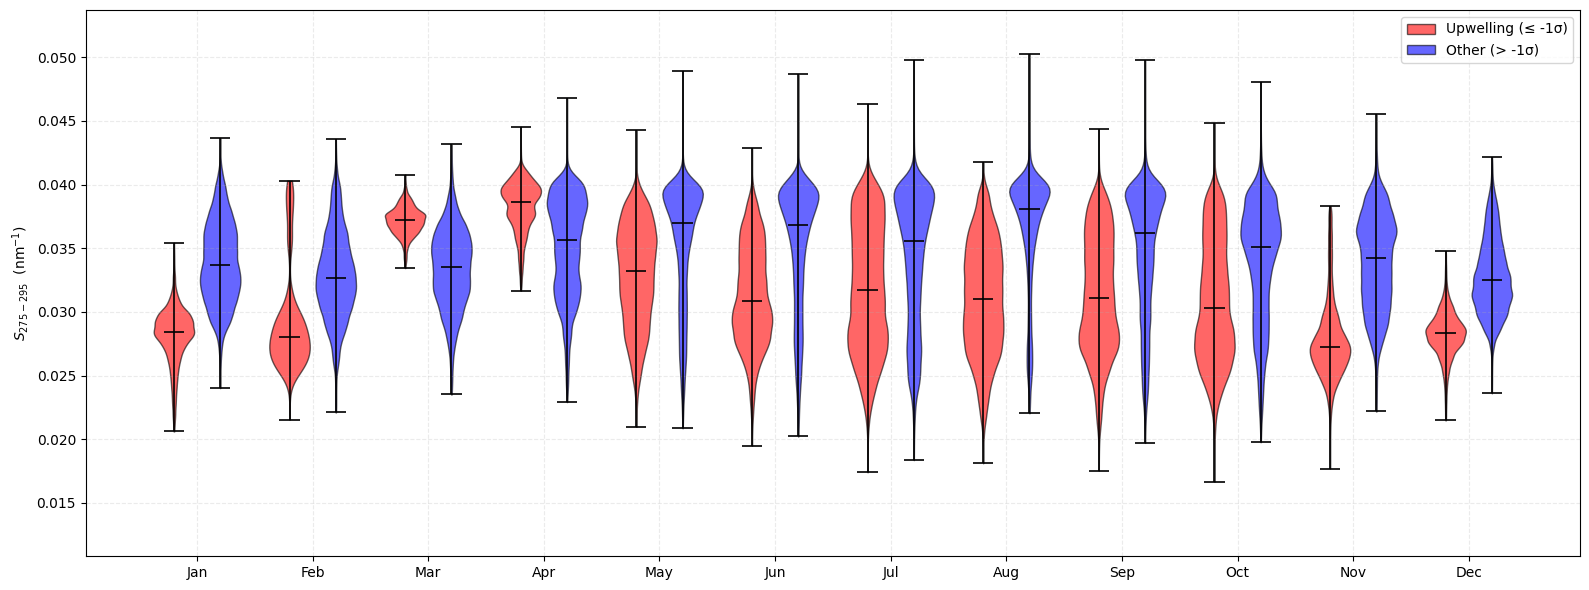

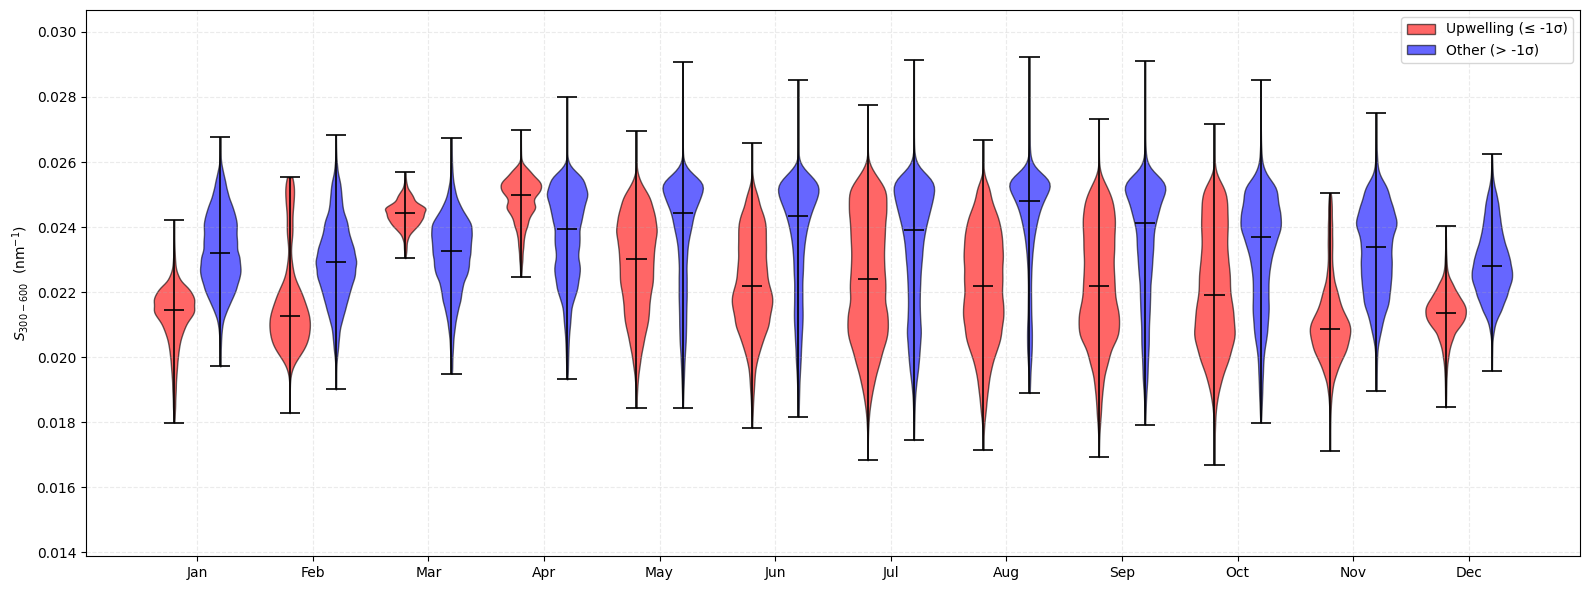

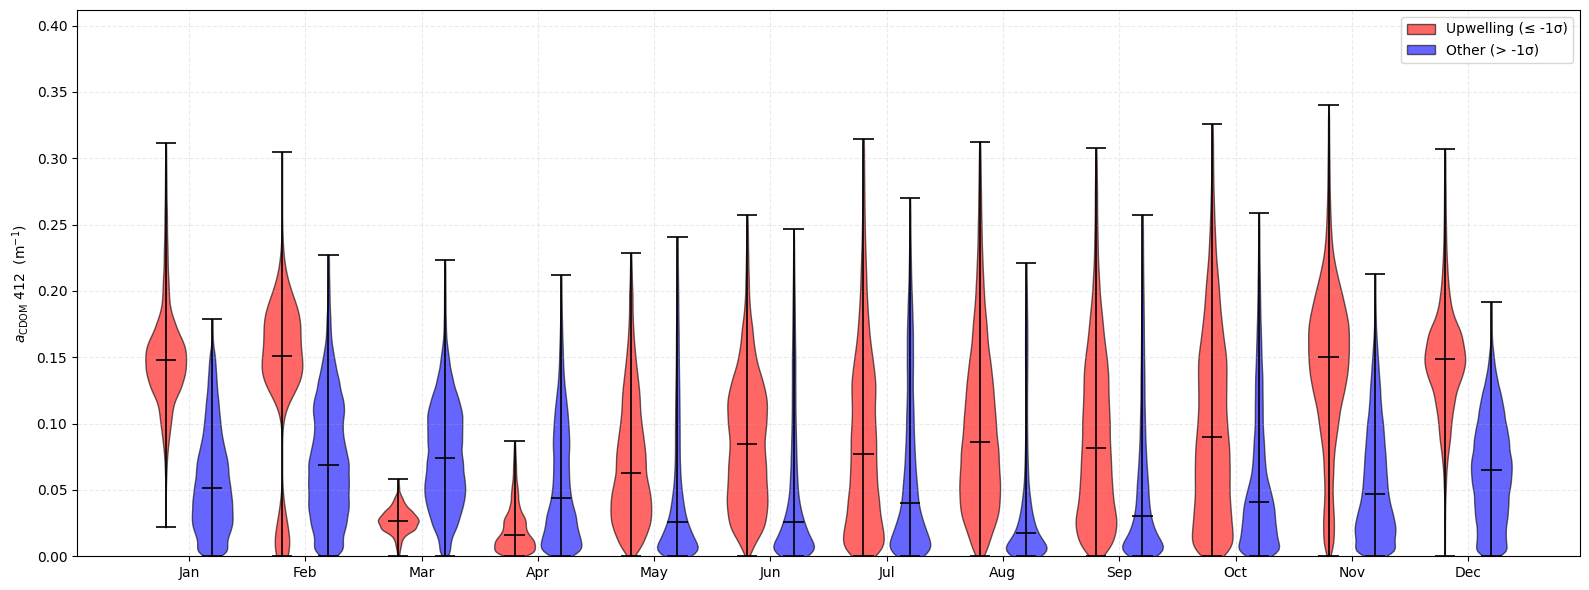

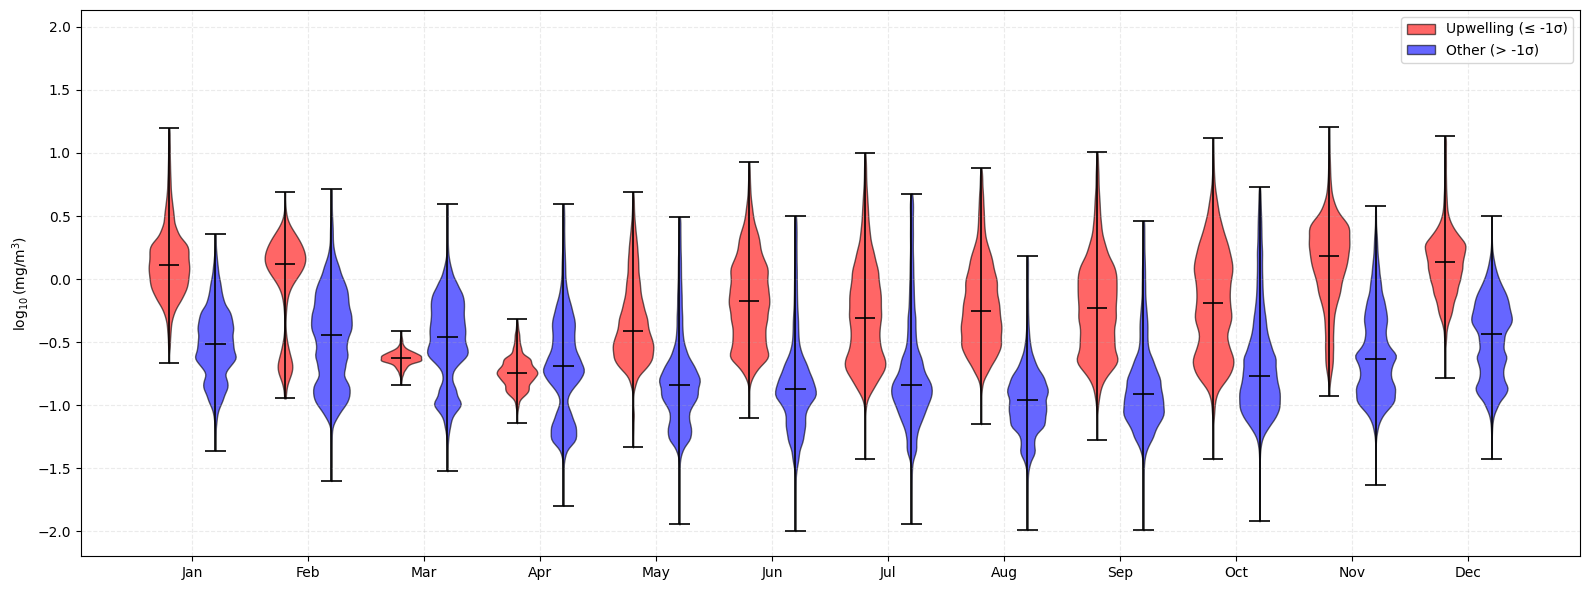

Generating plots for 2011...


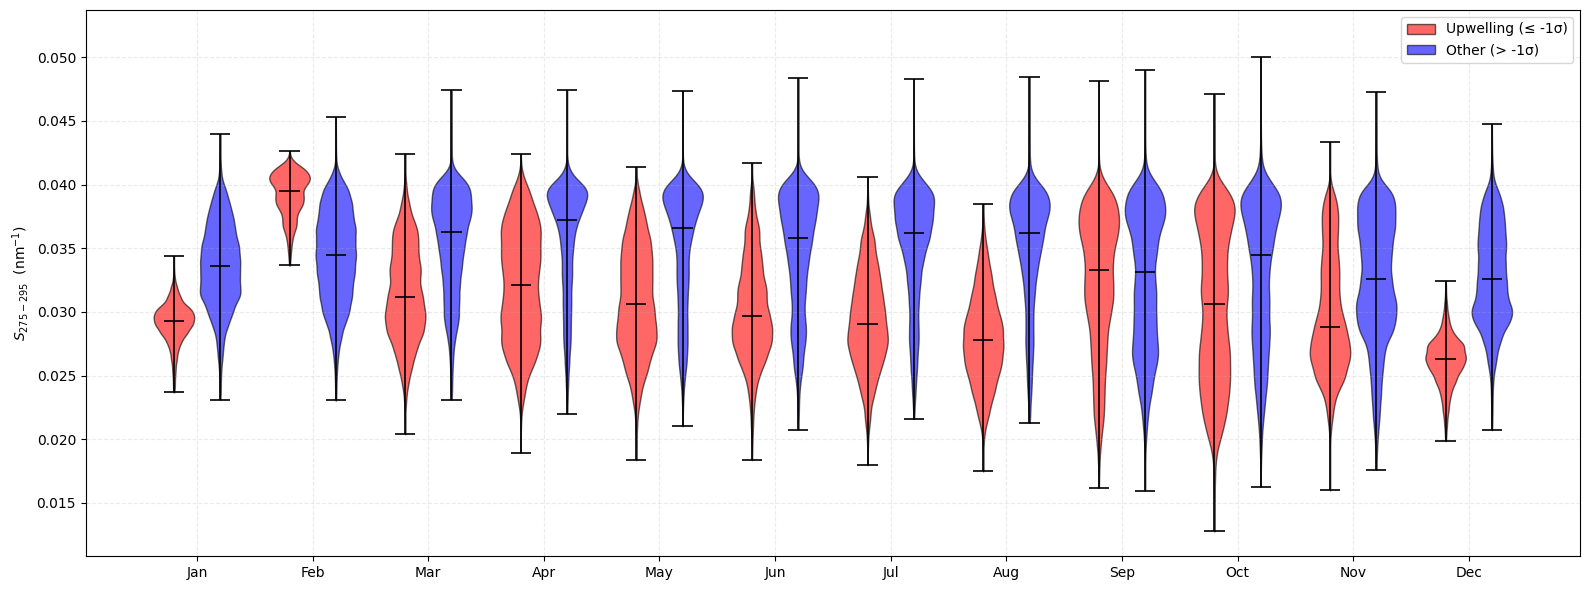

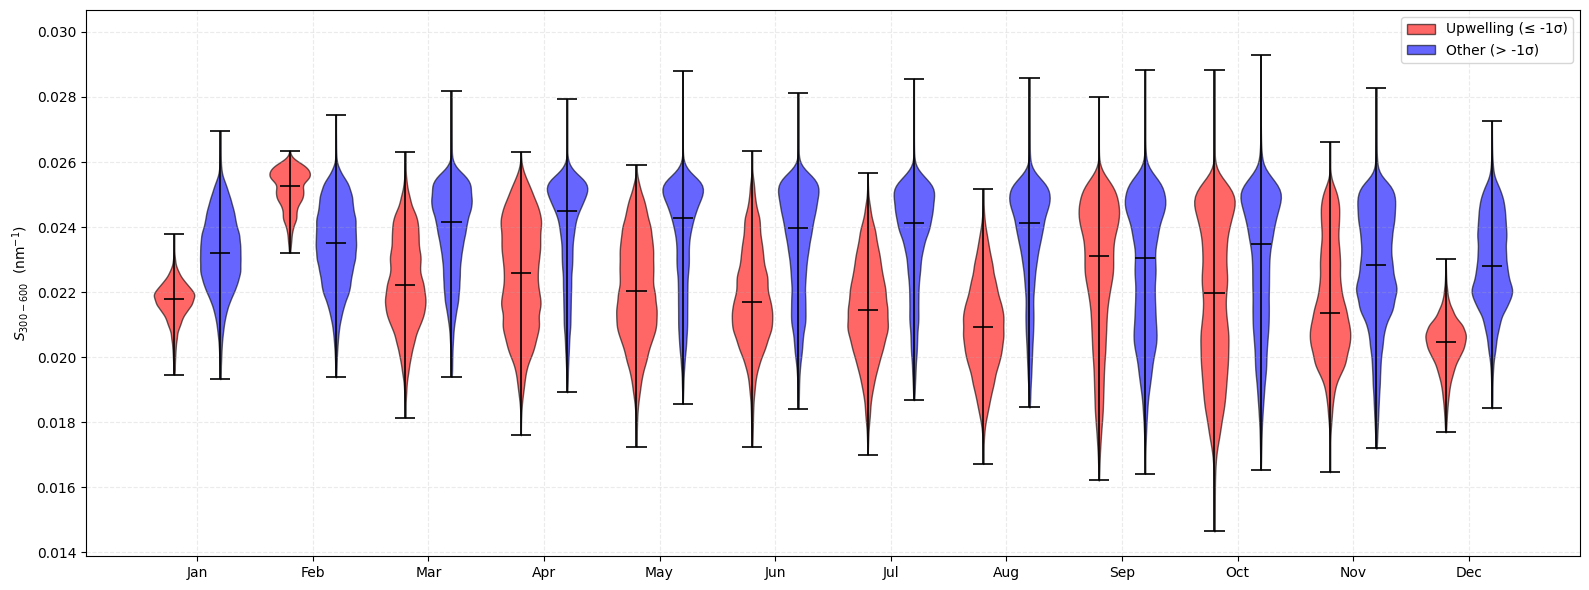

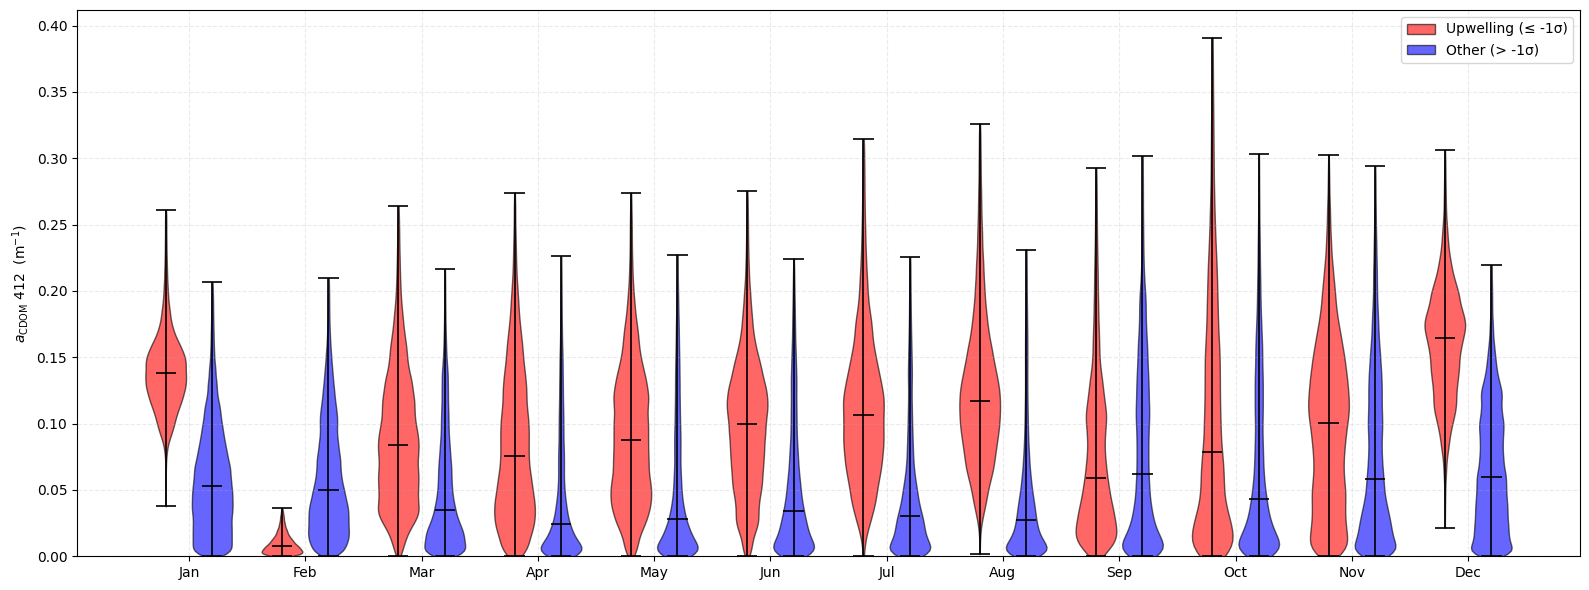

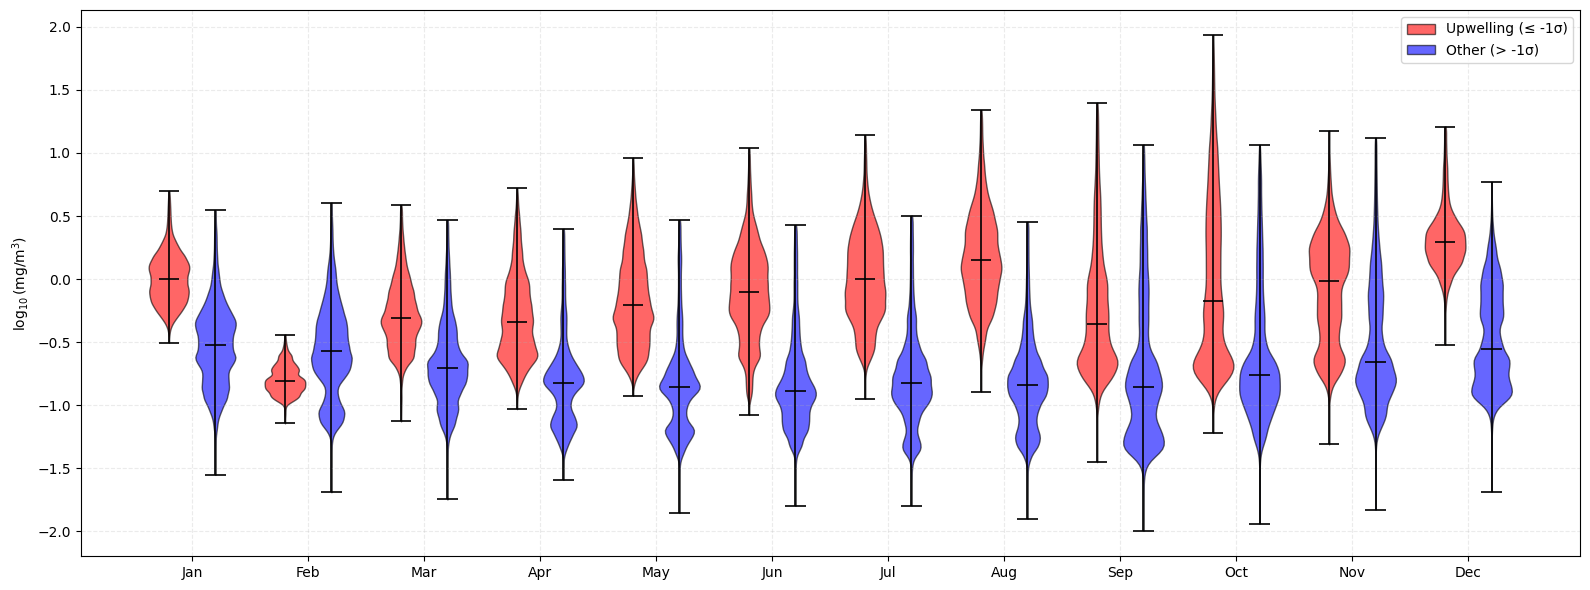

Generating plots for 2012...


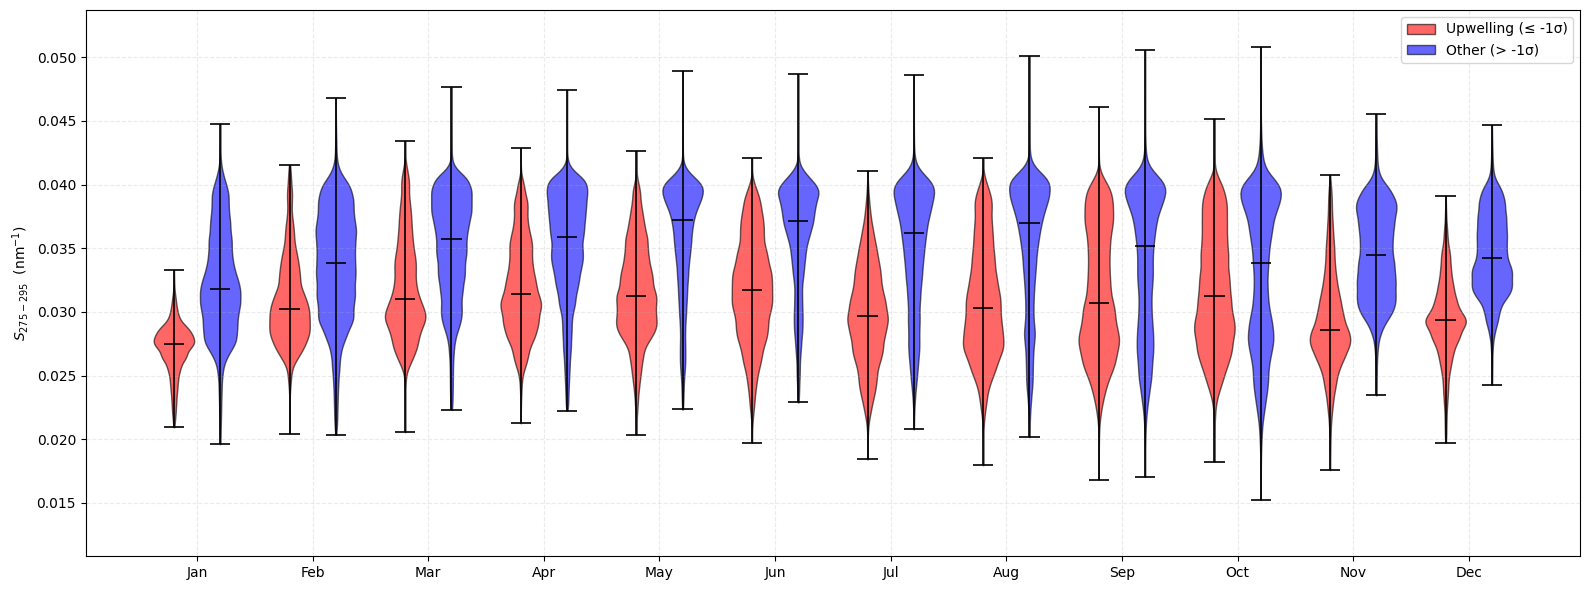

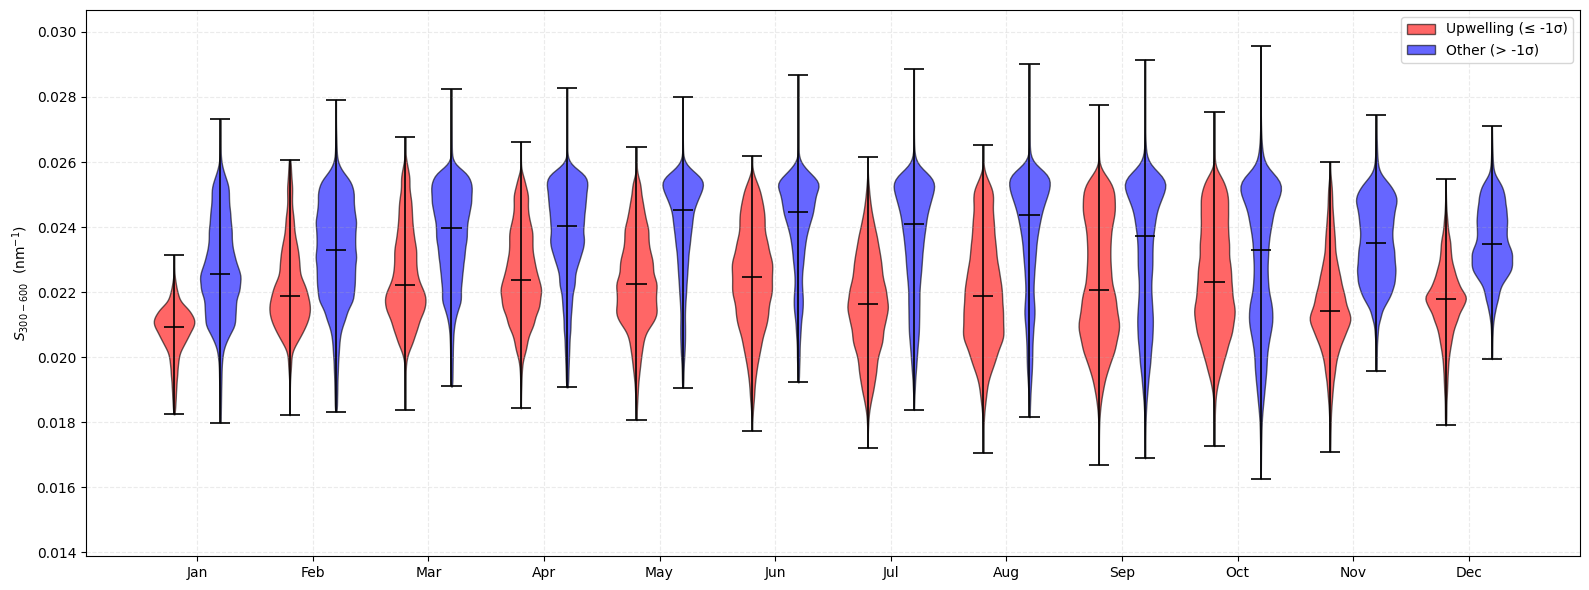

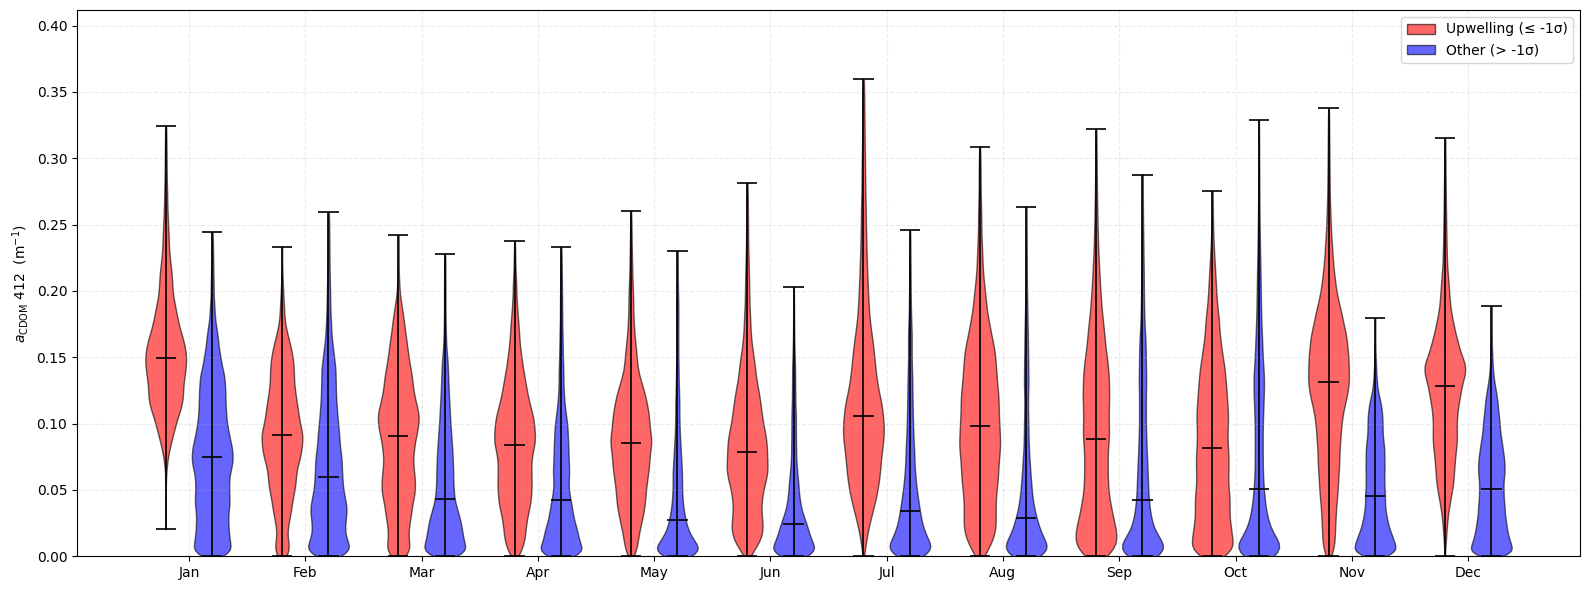

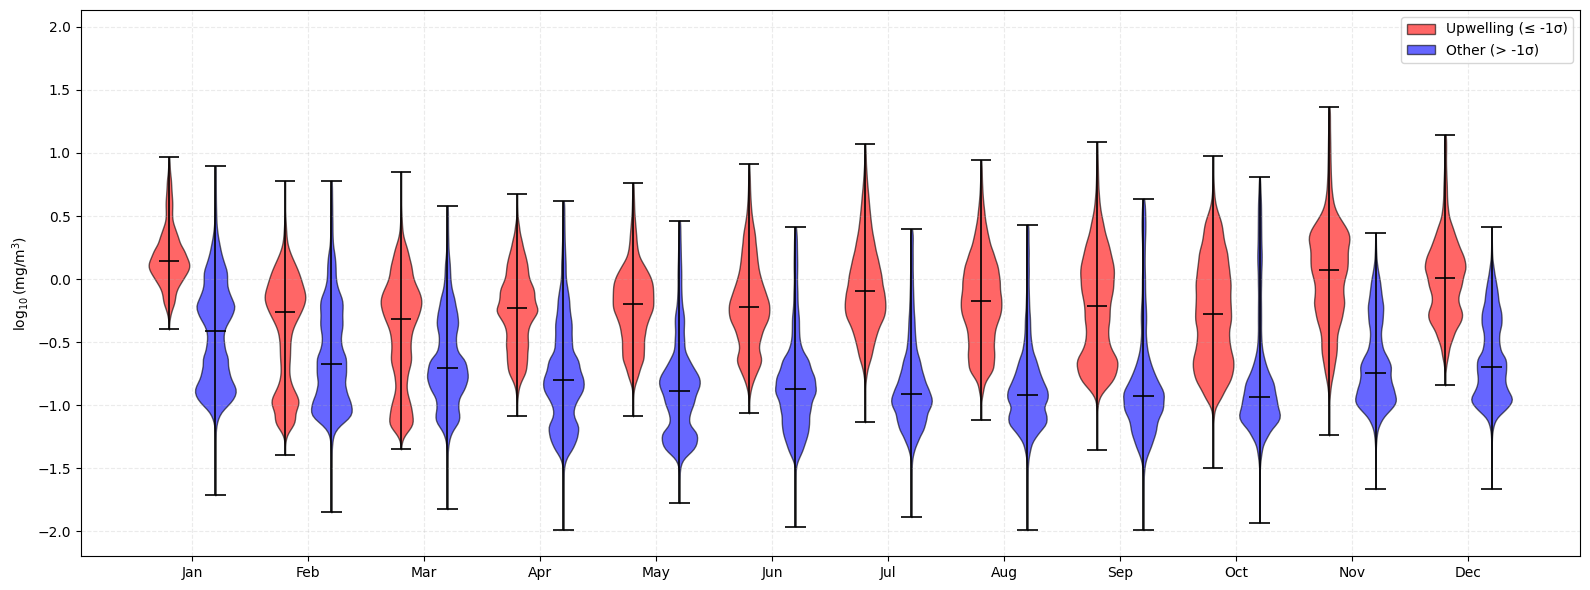

Generating plots for 2013...


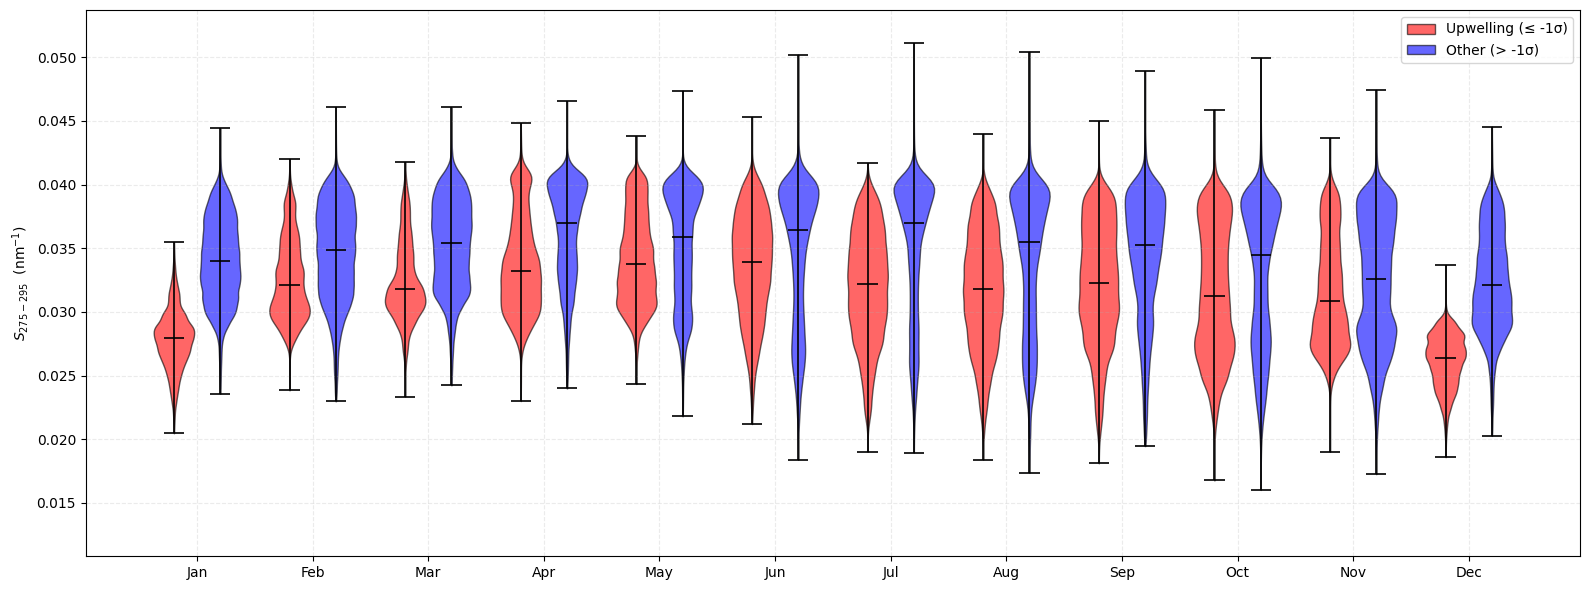

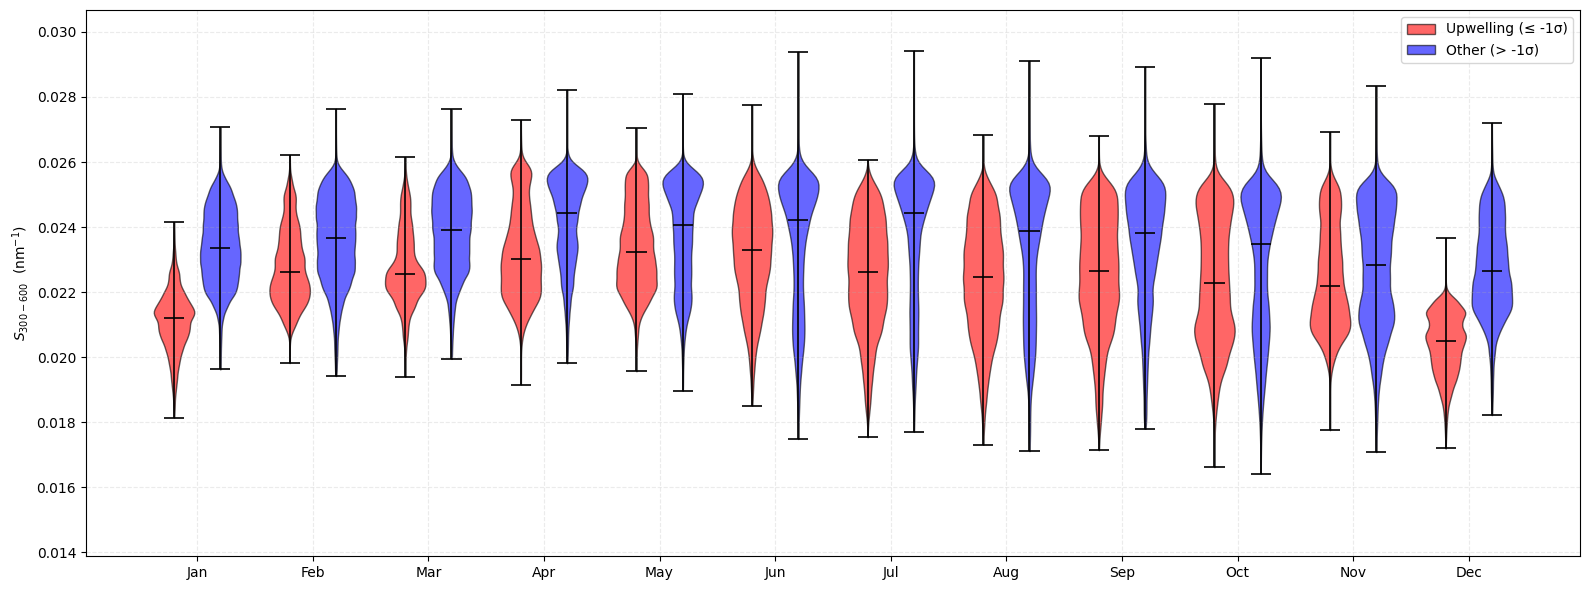

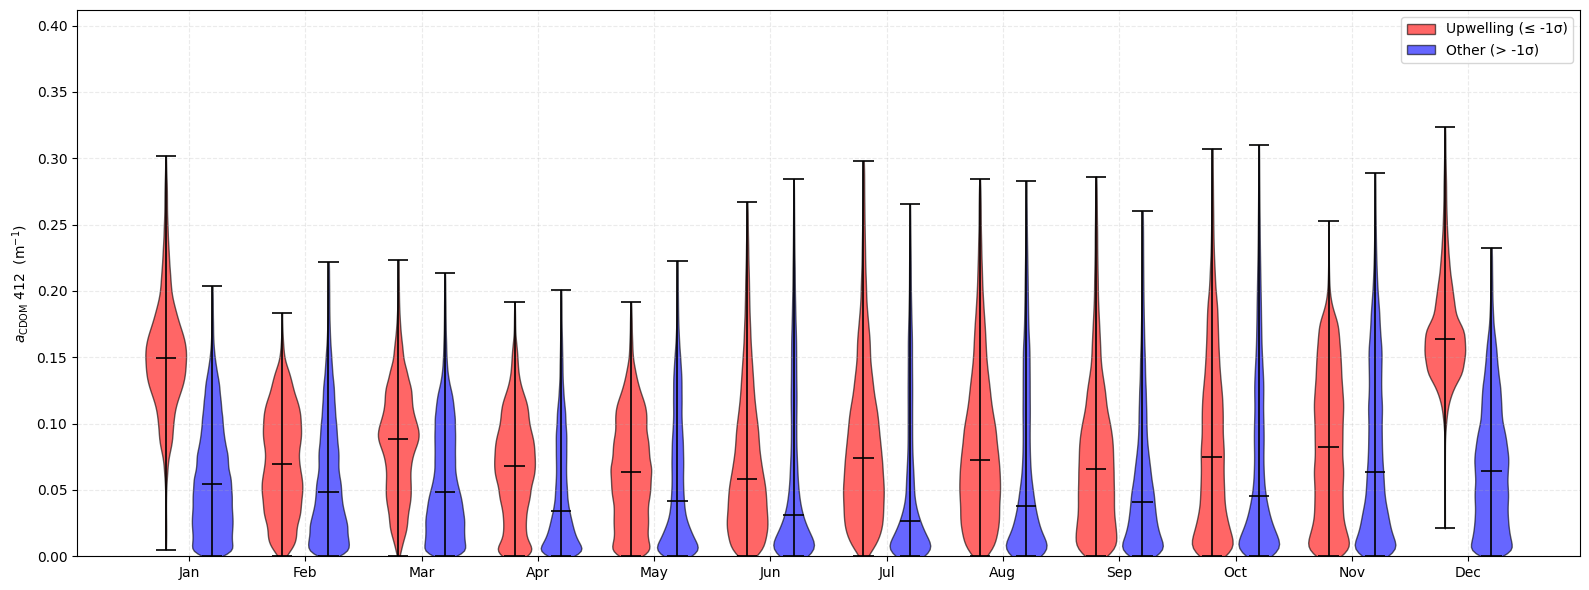

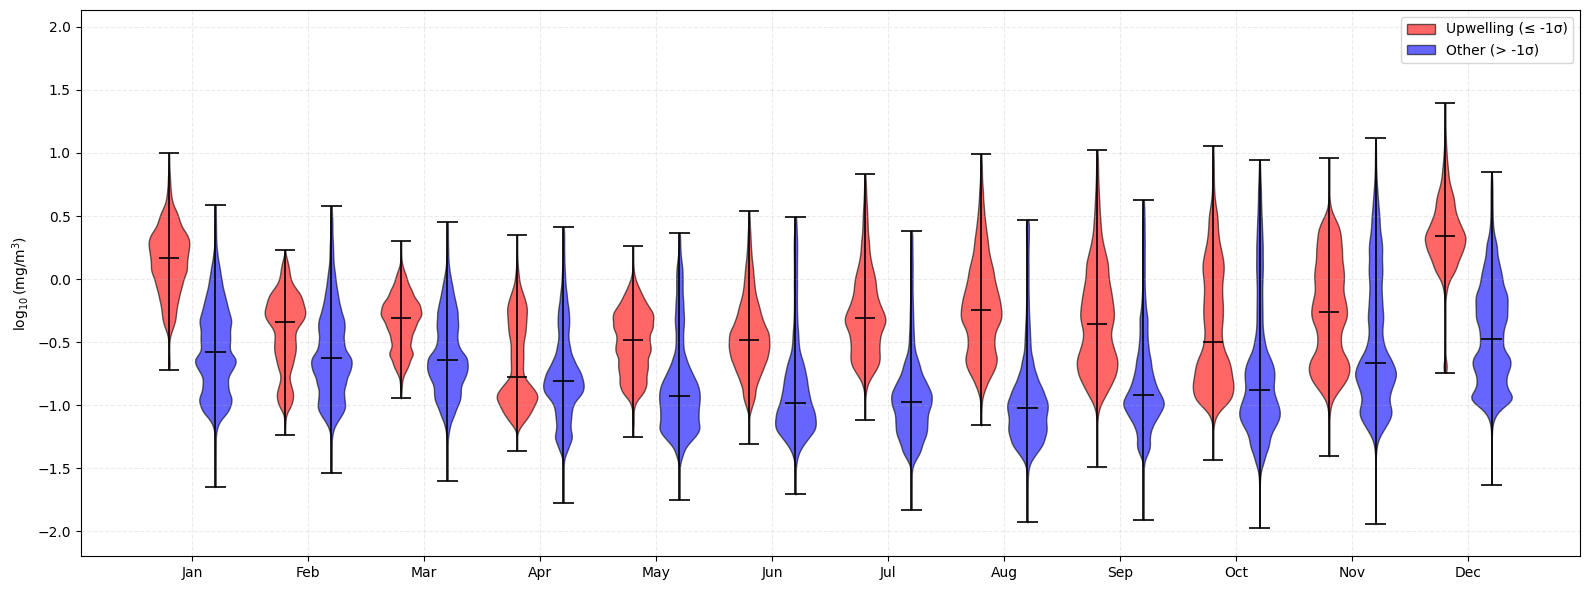

Generating plots for 2014...


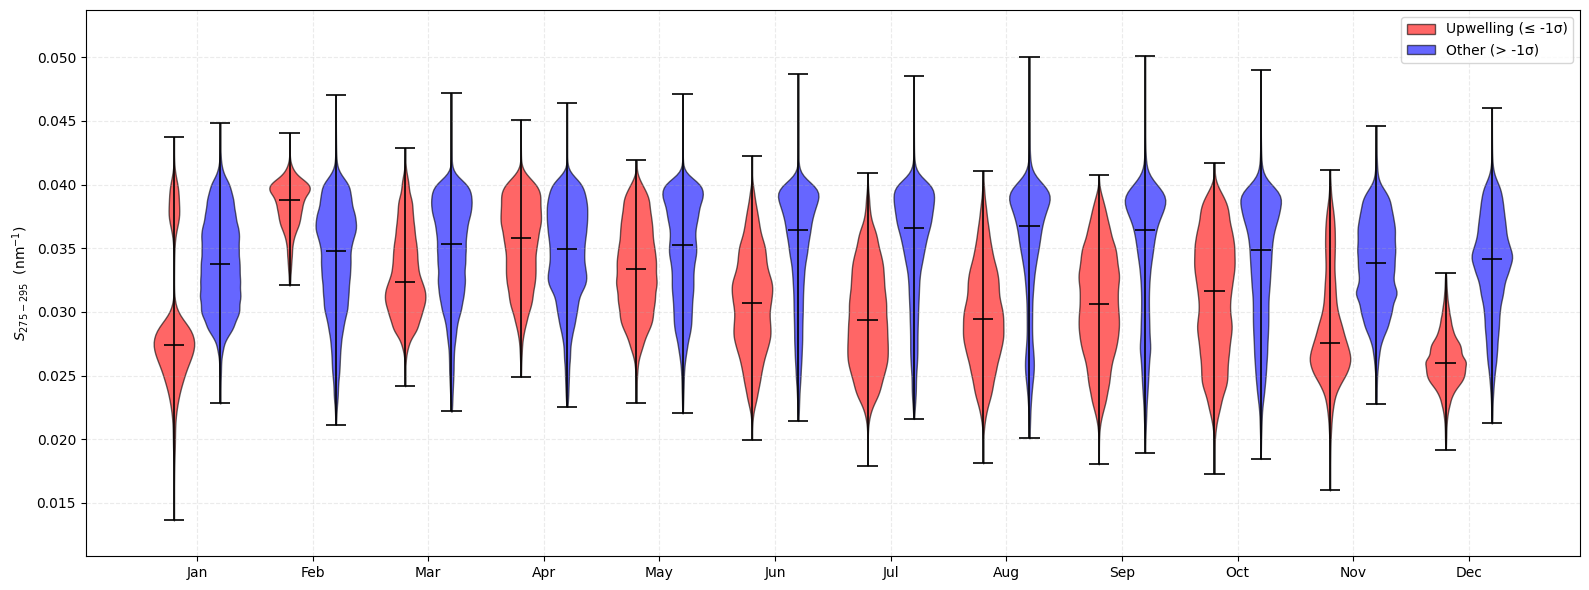

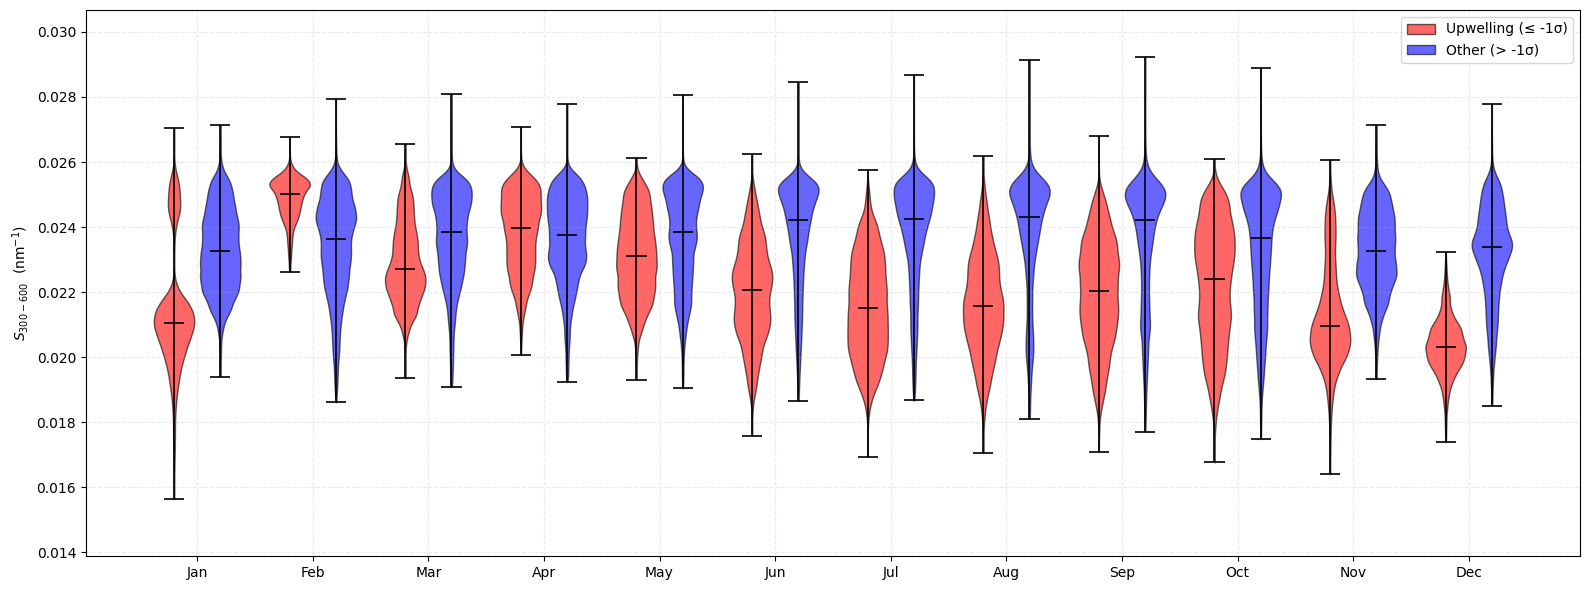

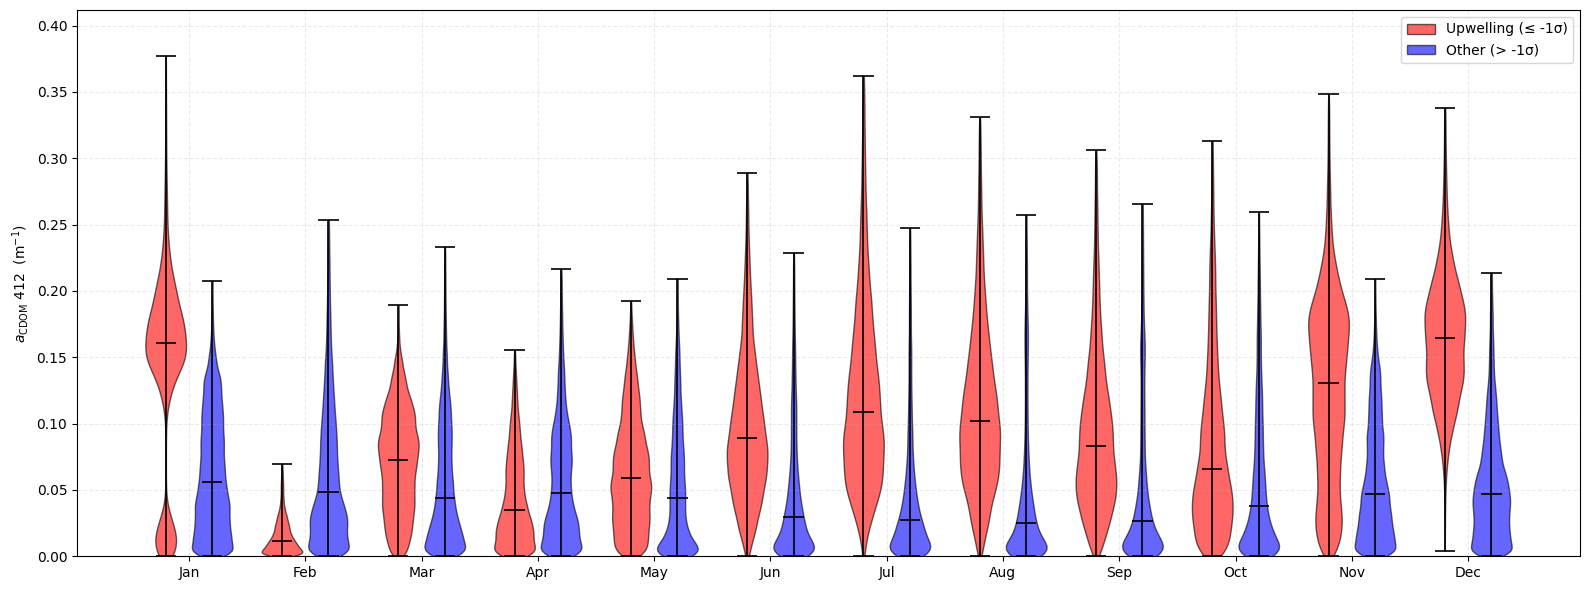

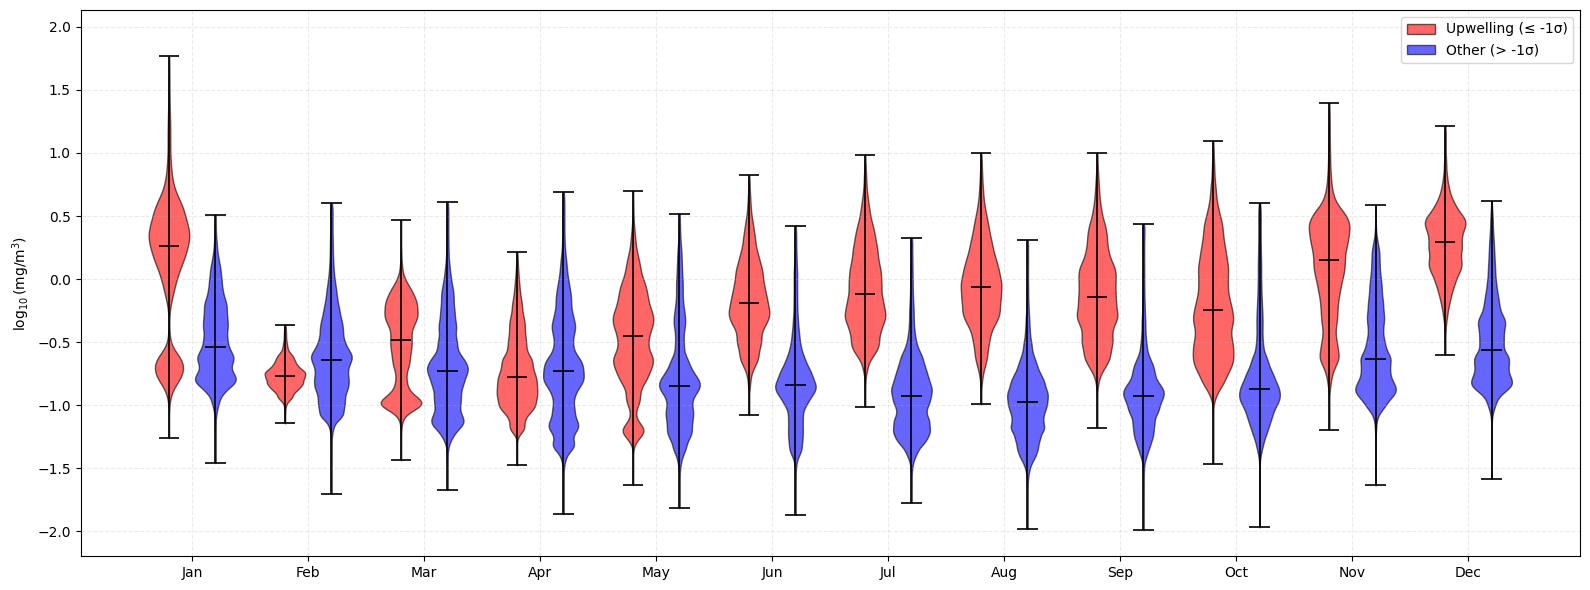

Generating plots for 2015...


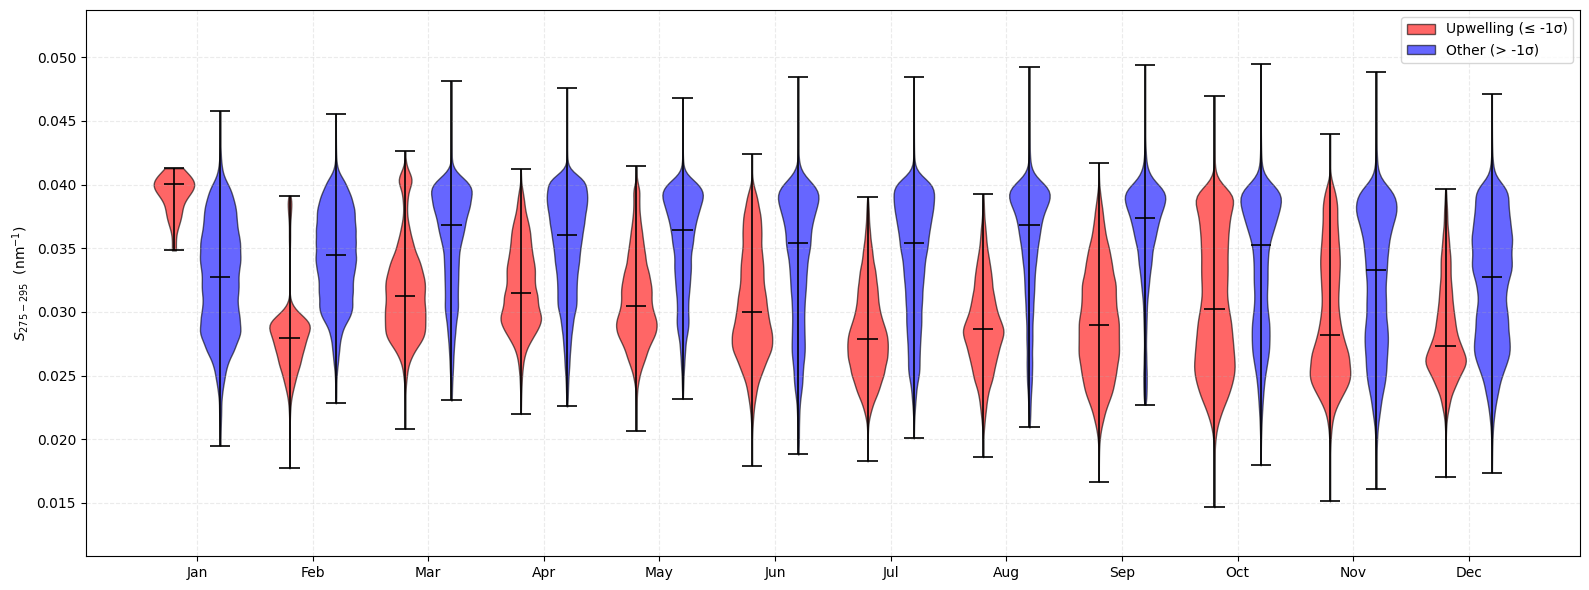

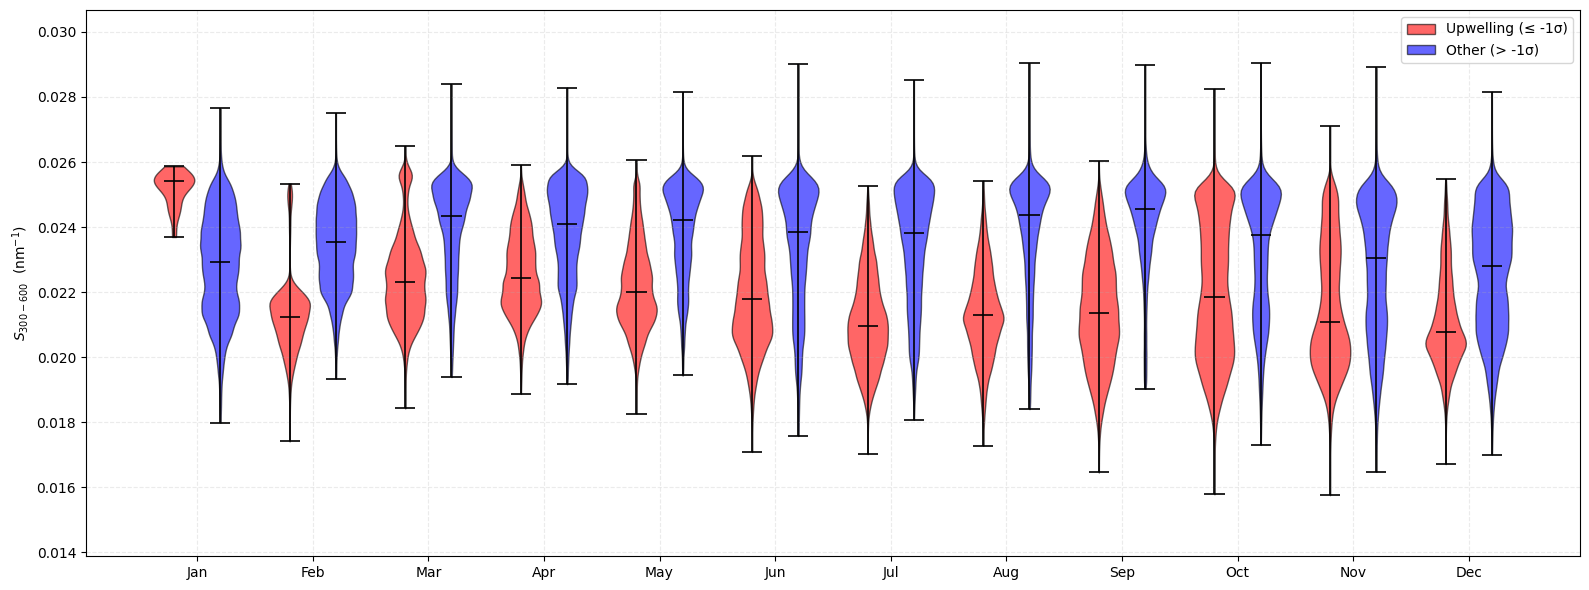

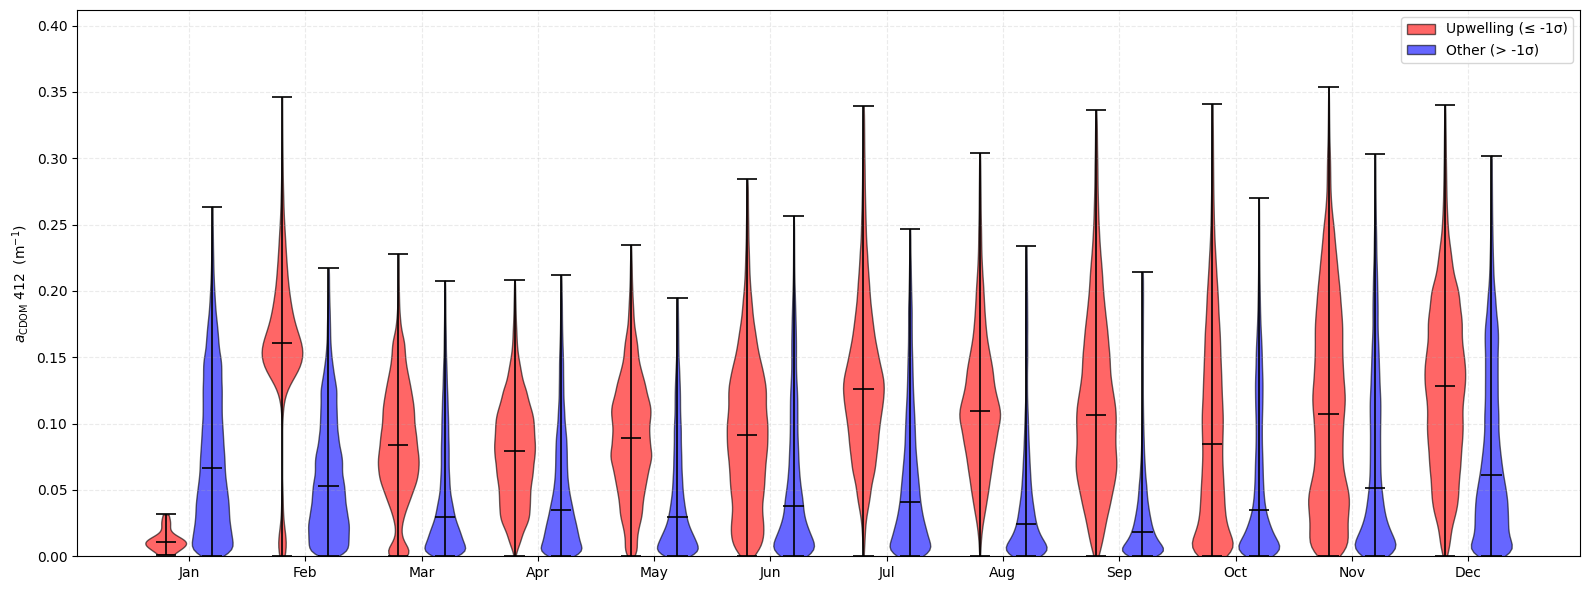

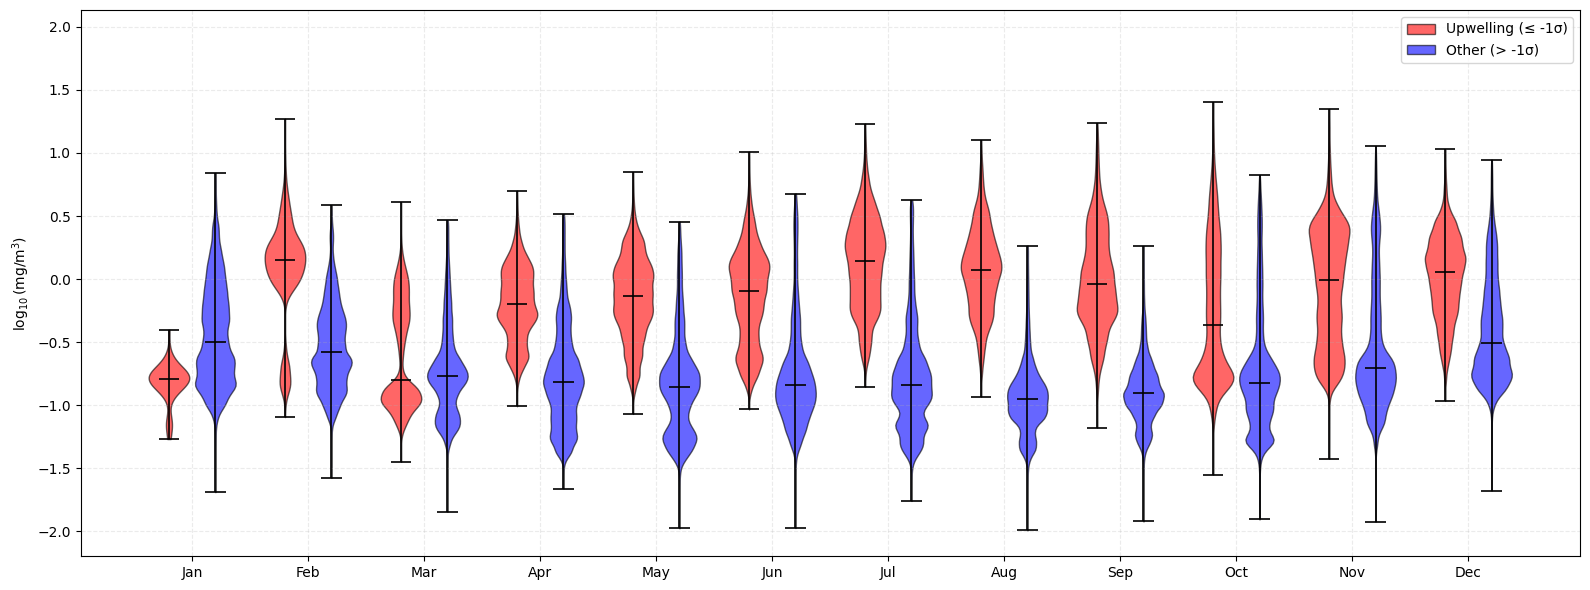

Generating plots for 2016...


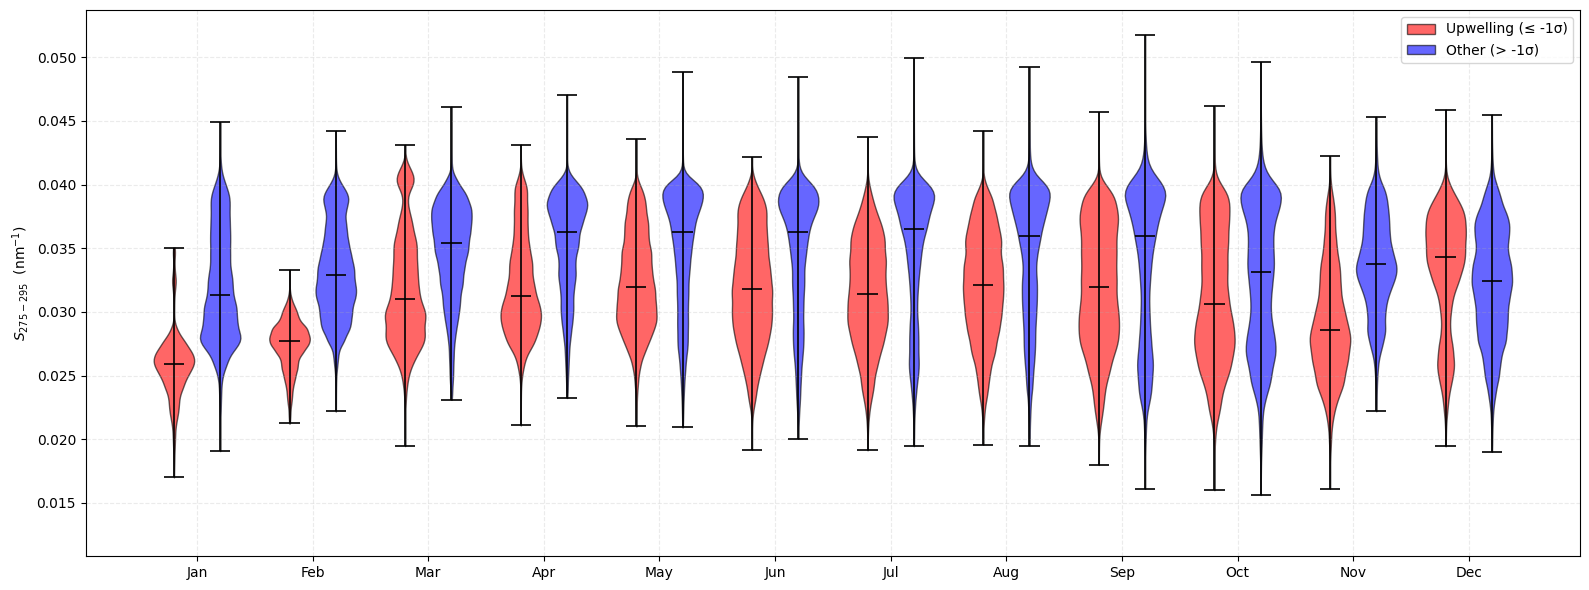

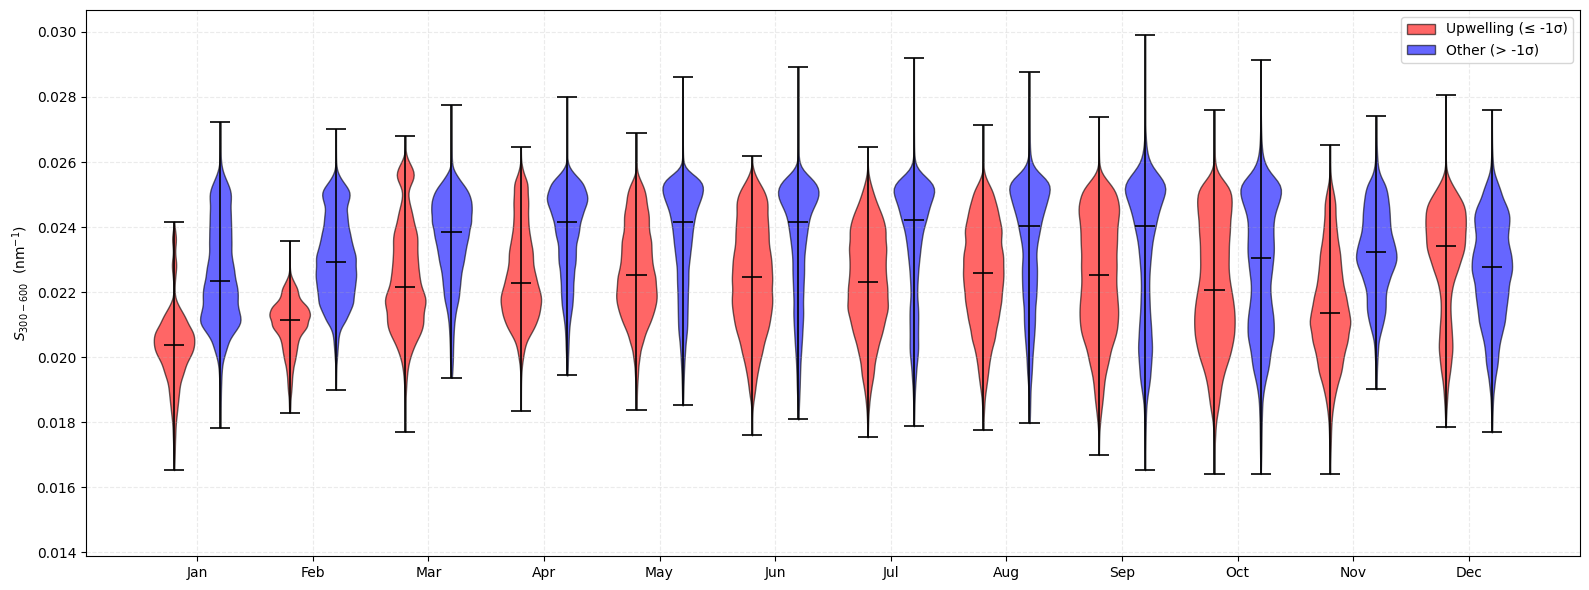

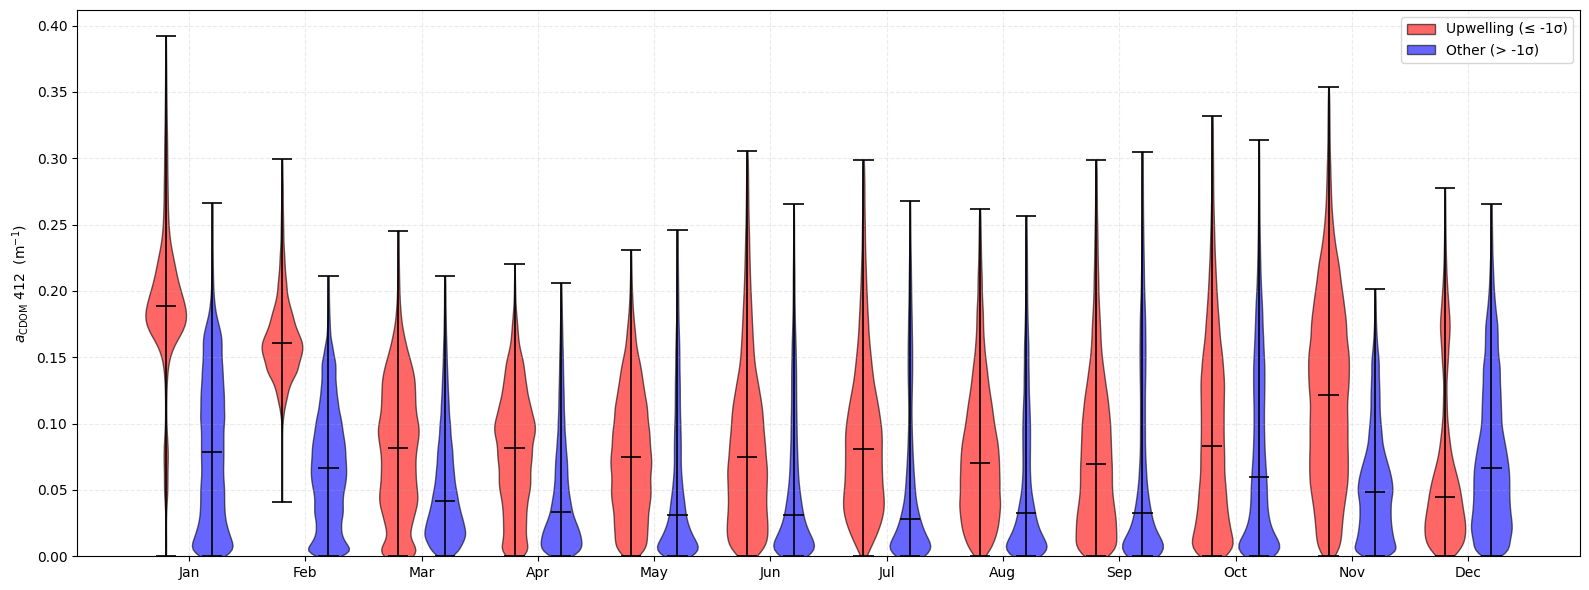

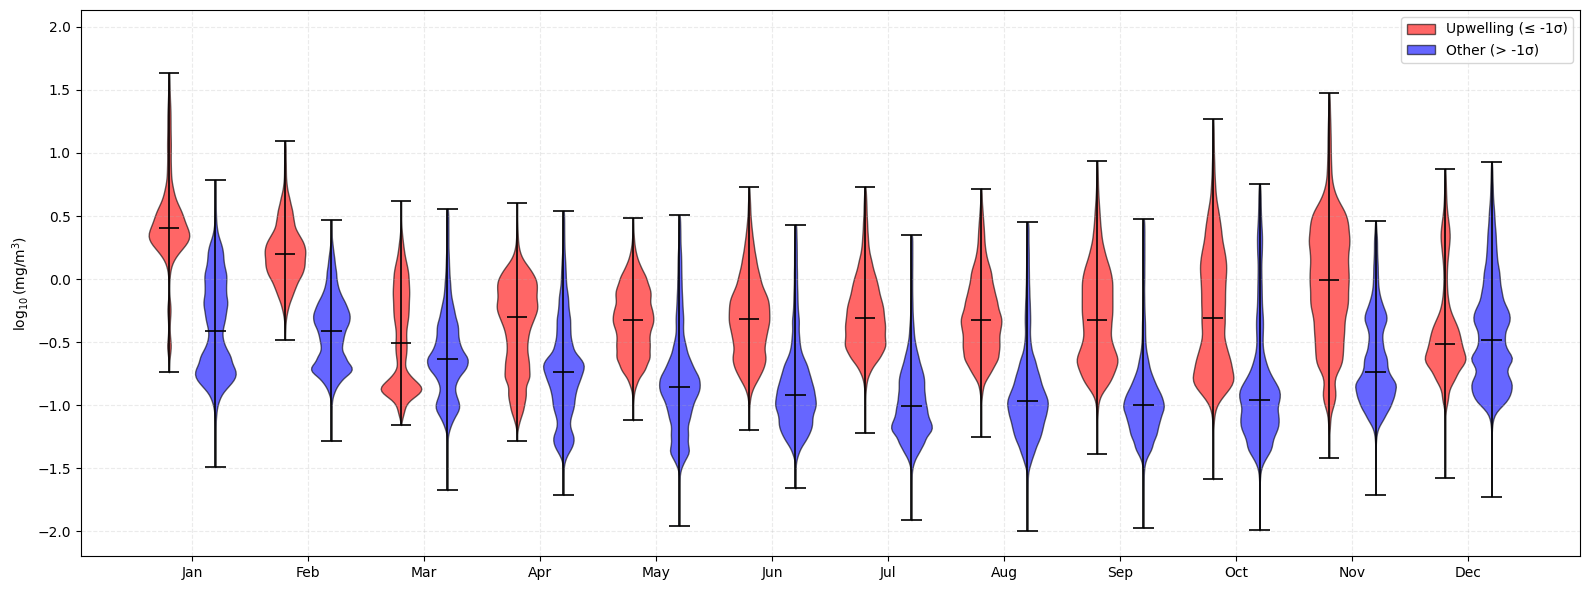

Generating plots for 2017...


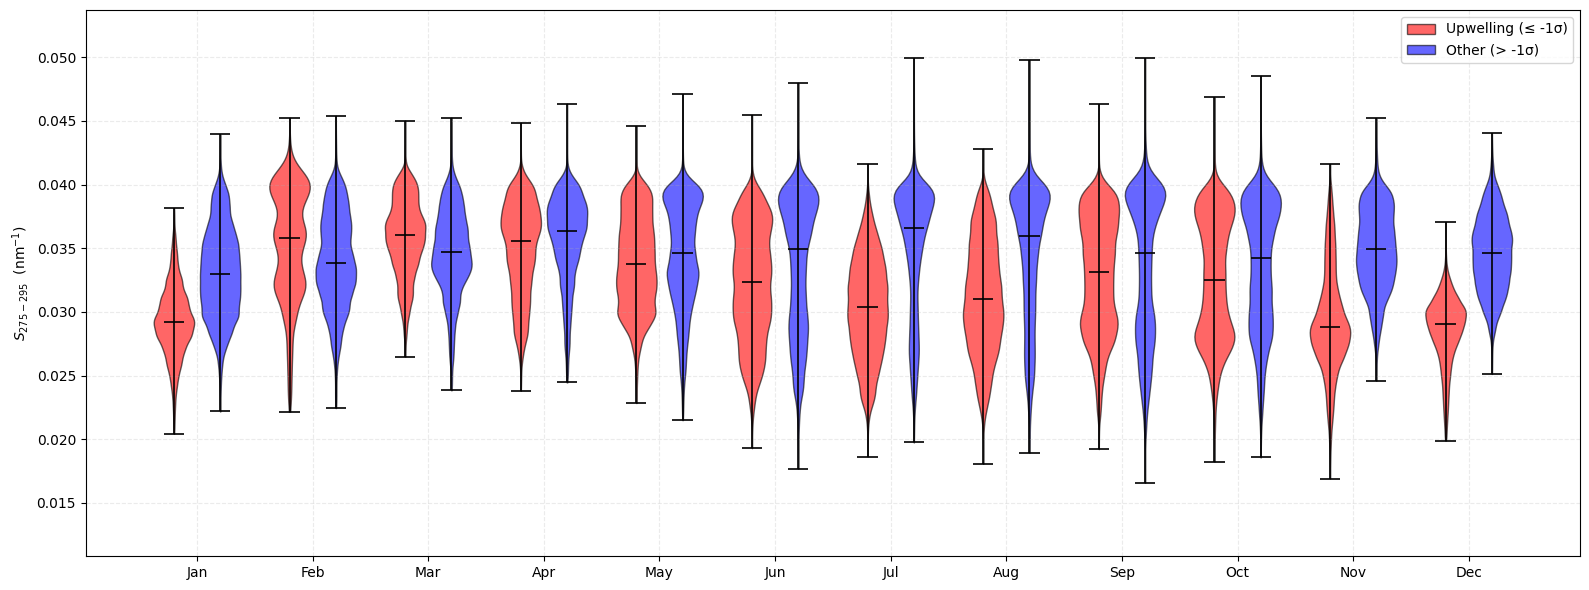

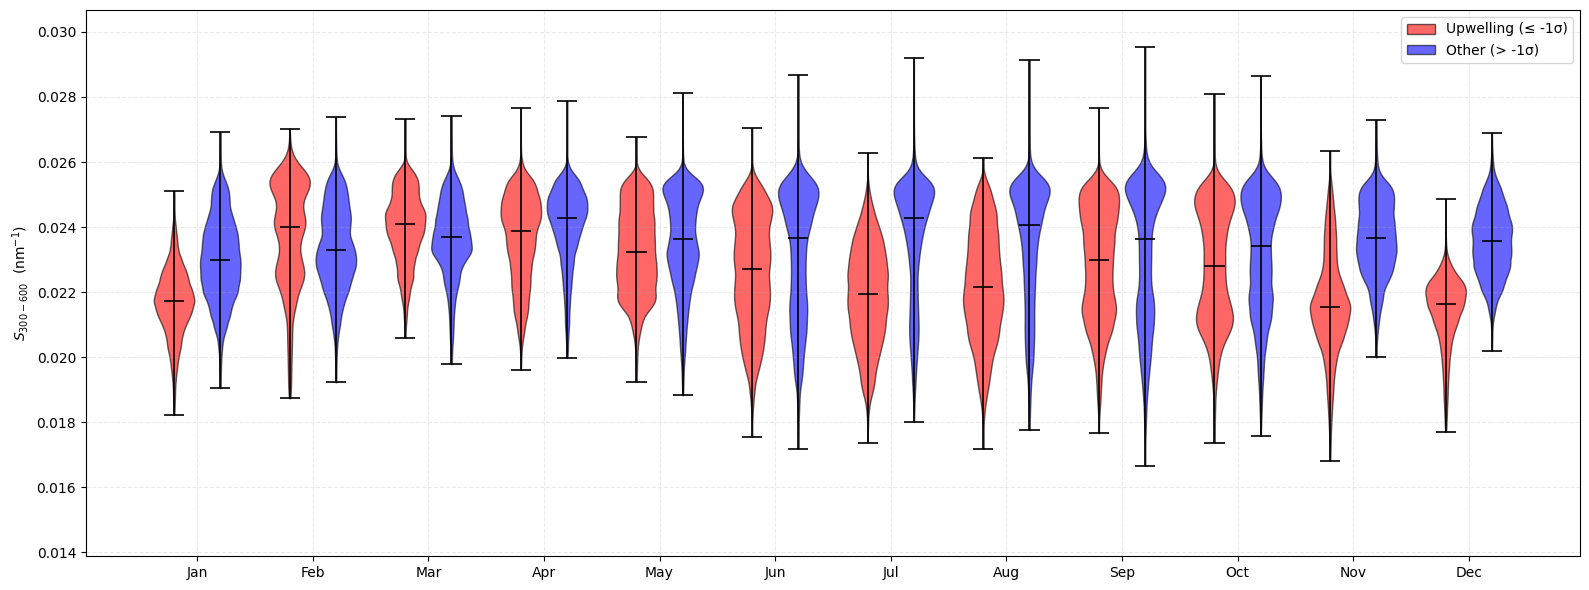

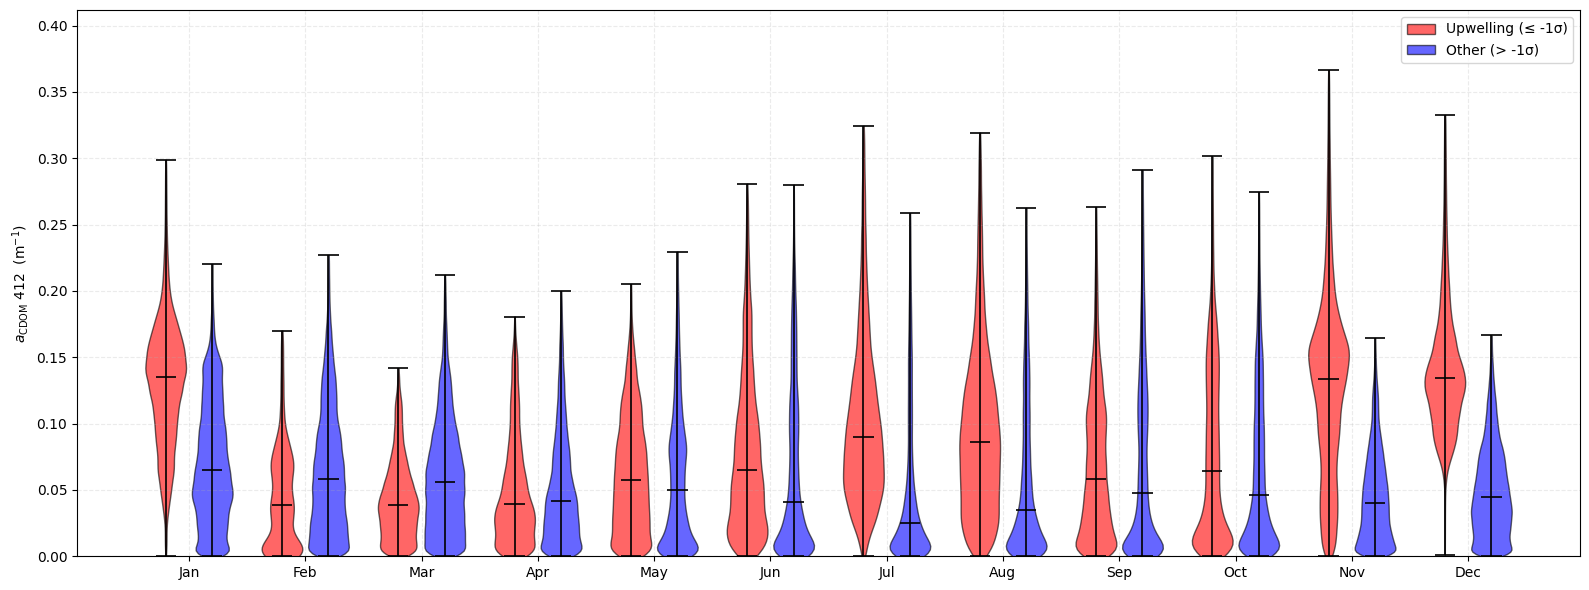

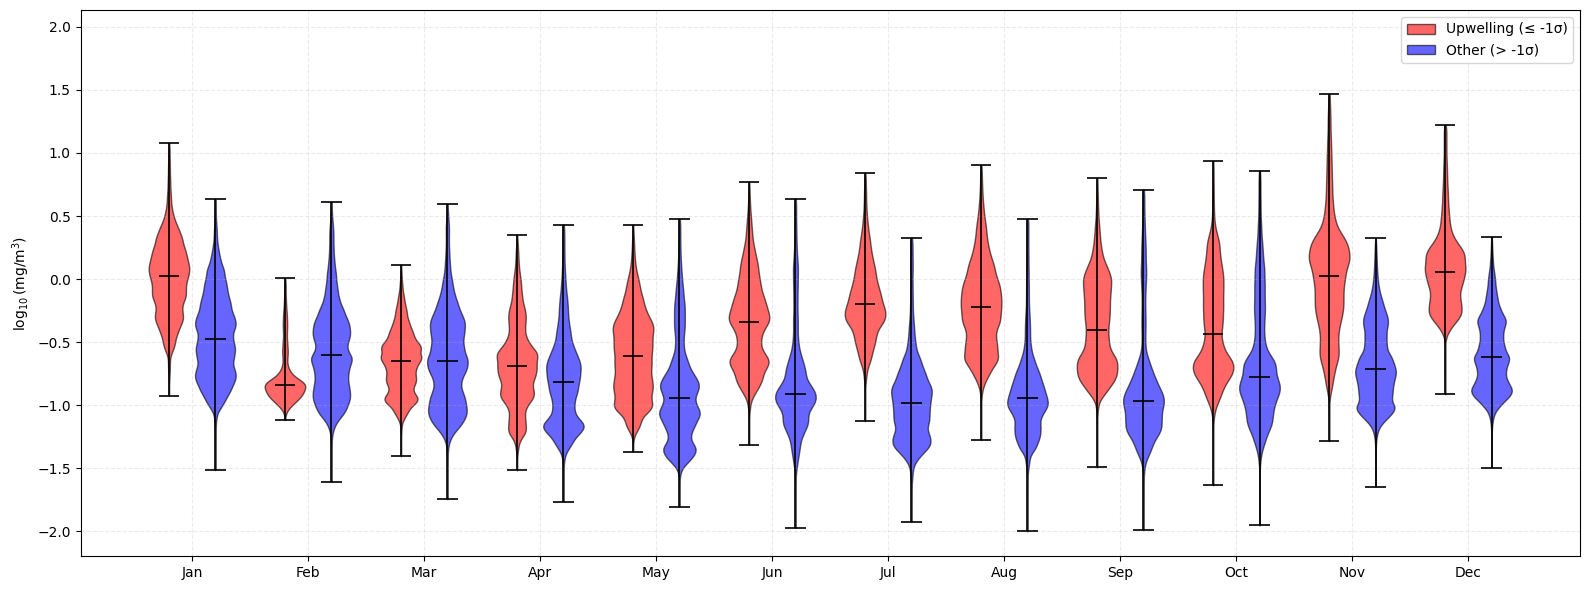

Generating plots for 2018...


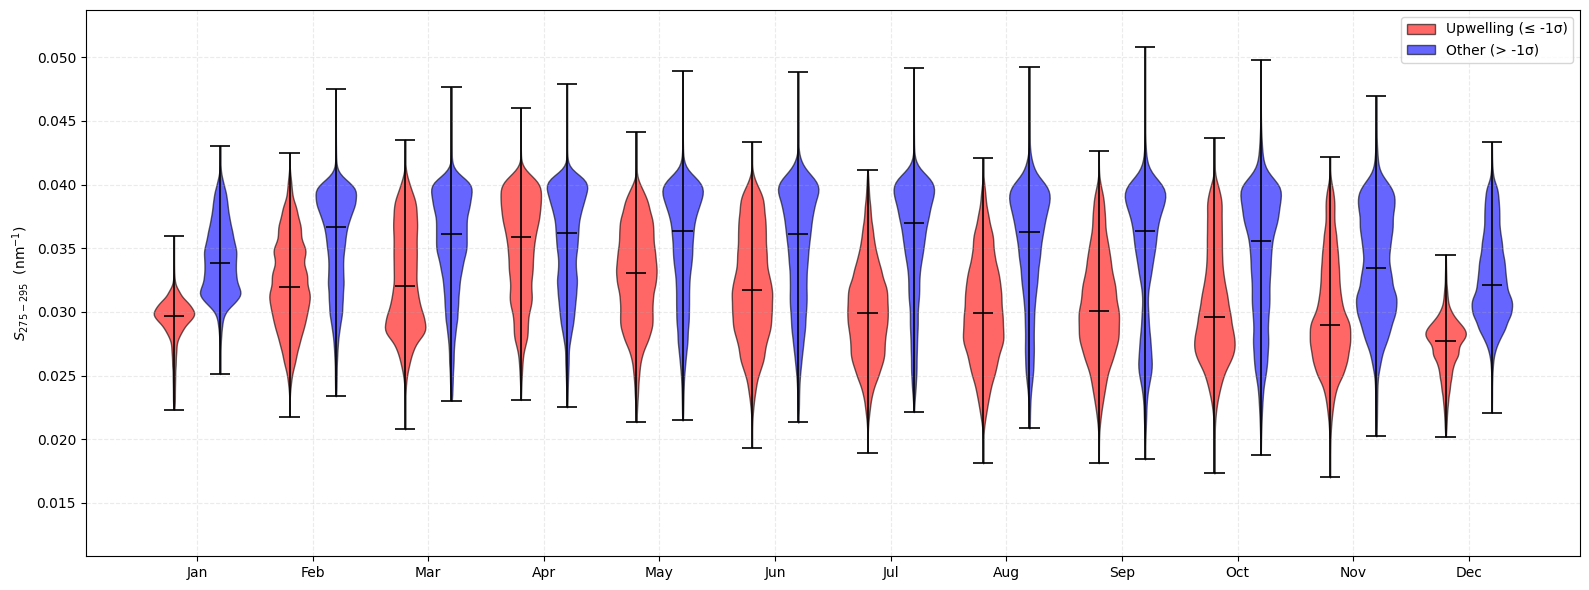

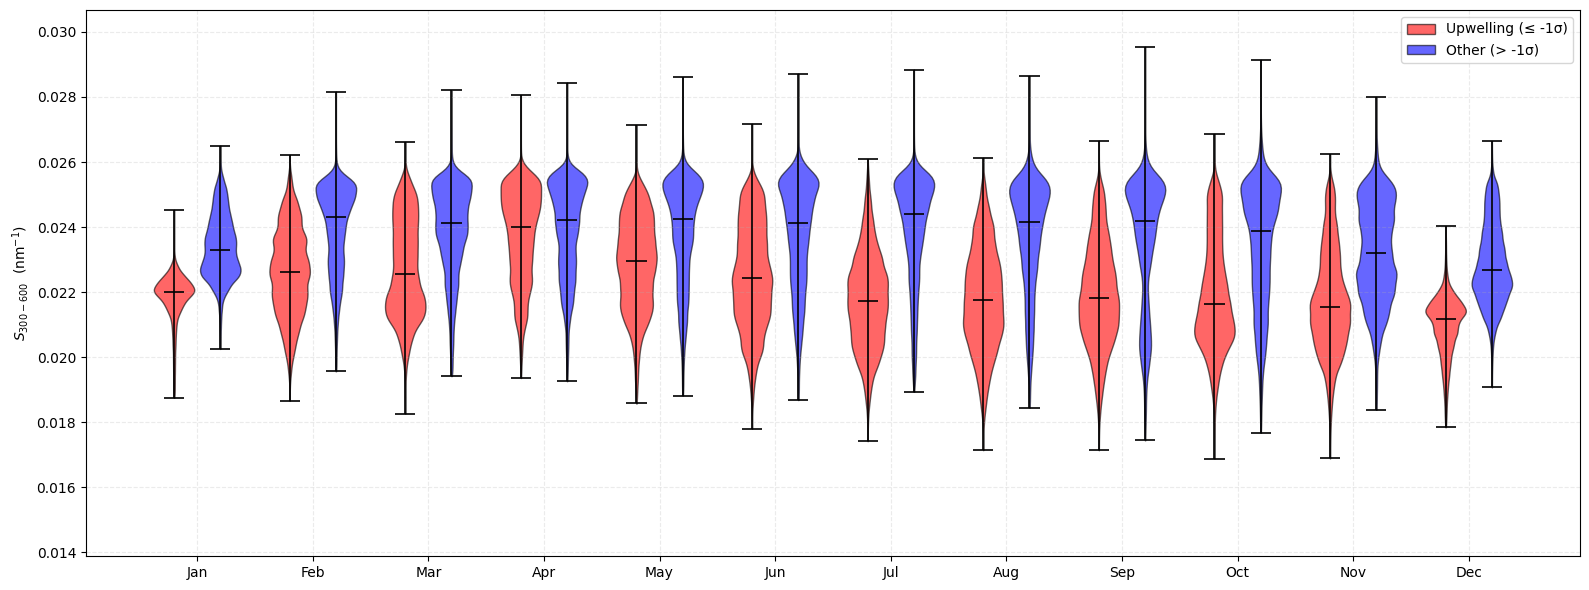

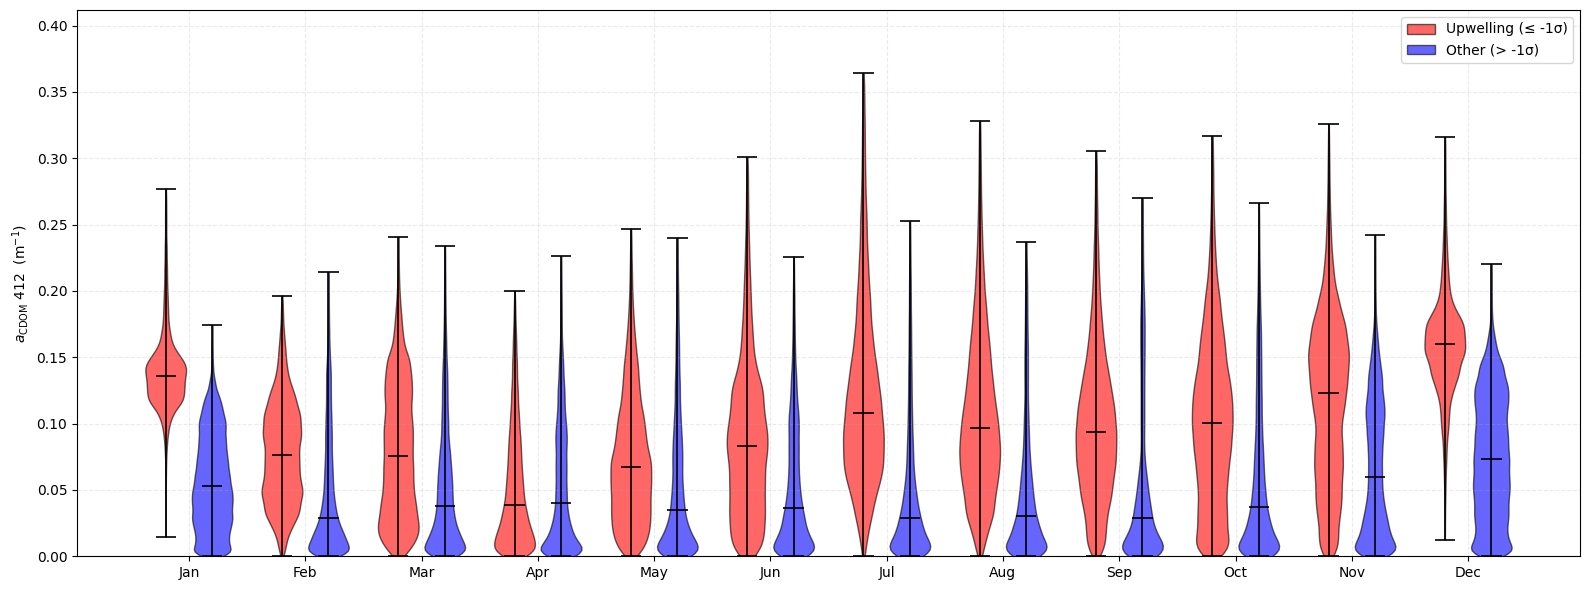

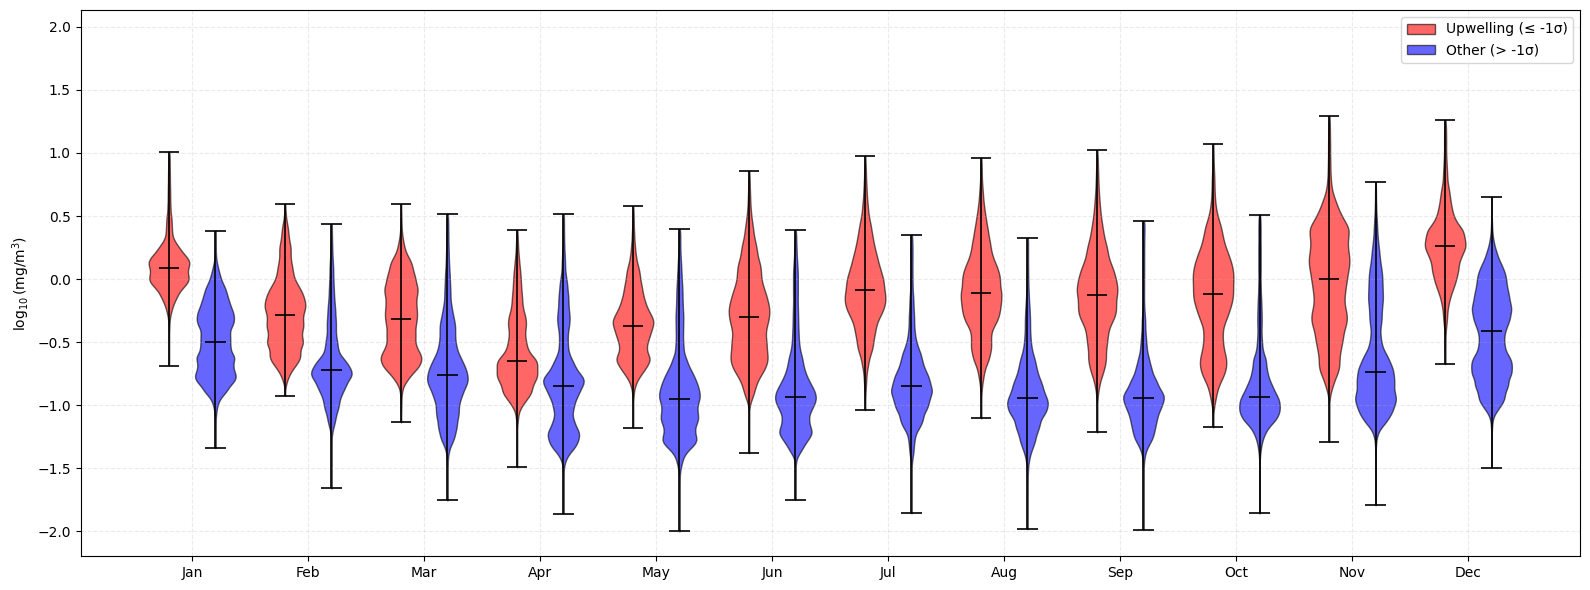

Generating plots for 2019...


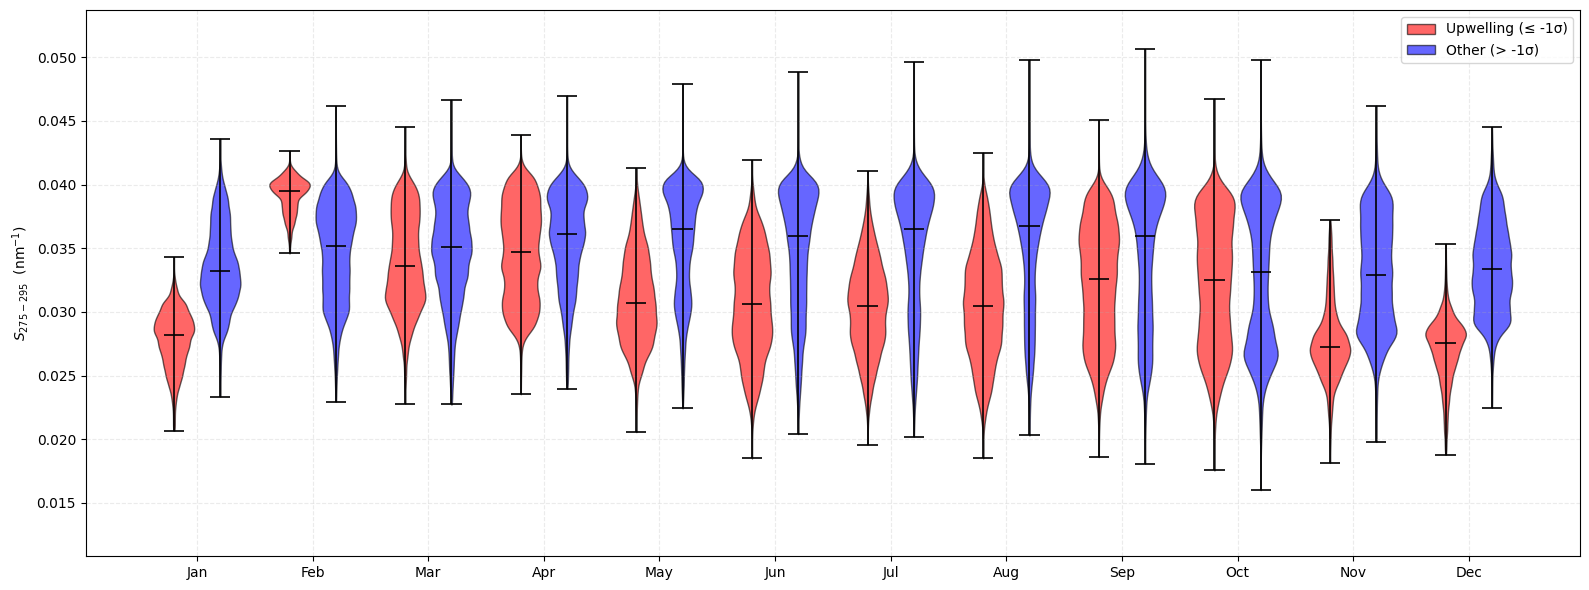

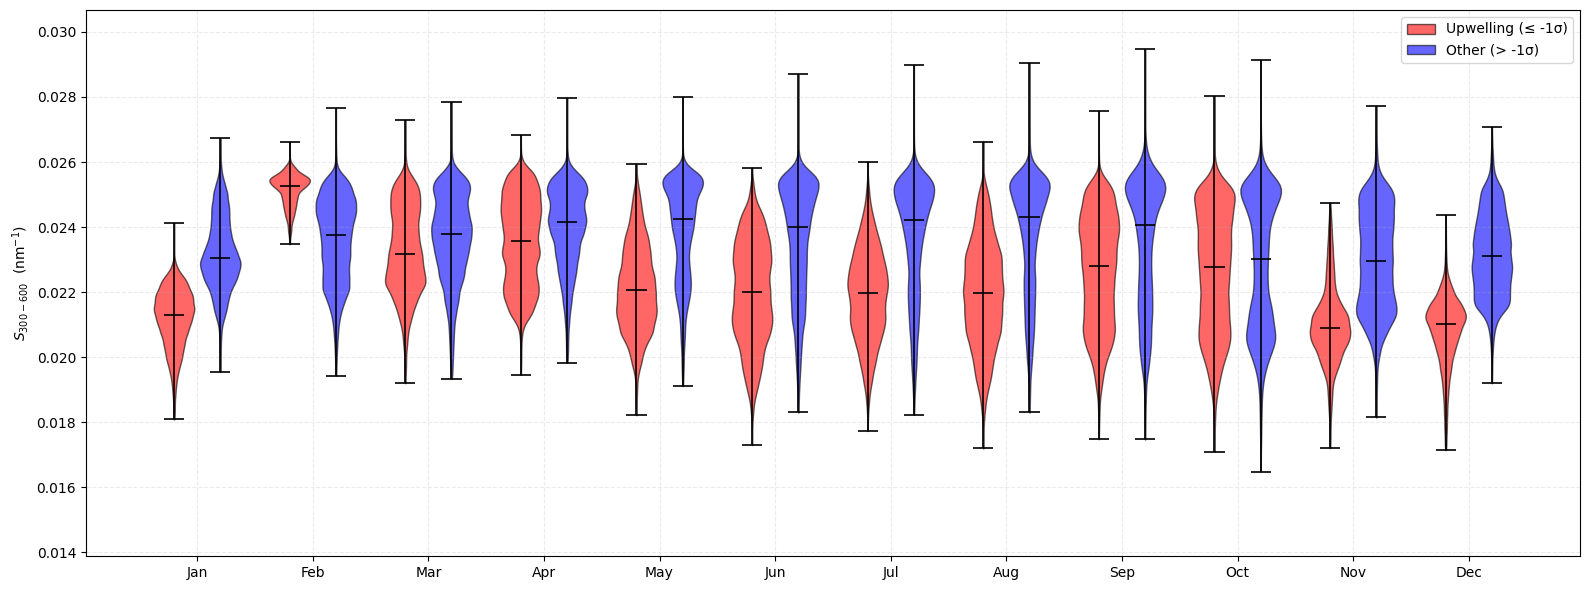

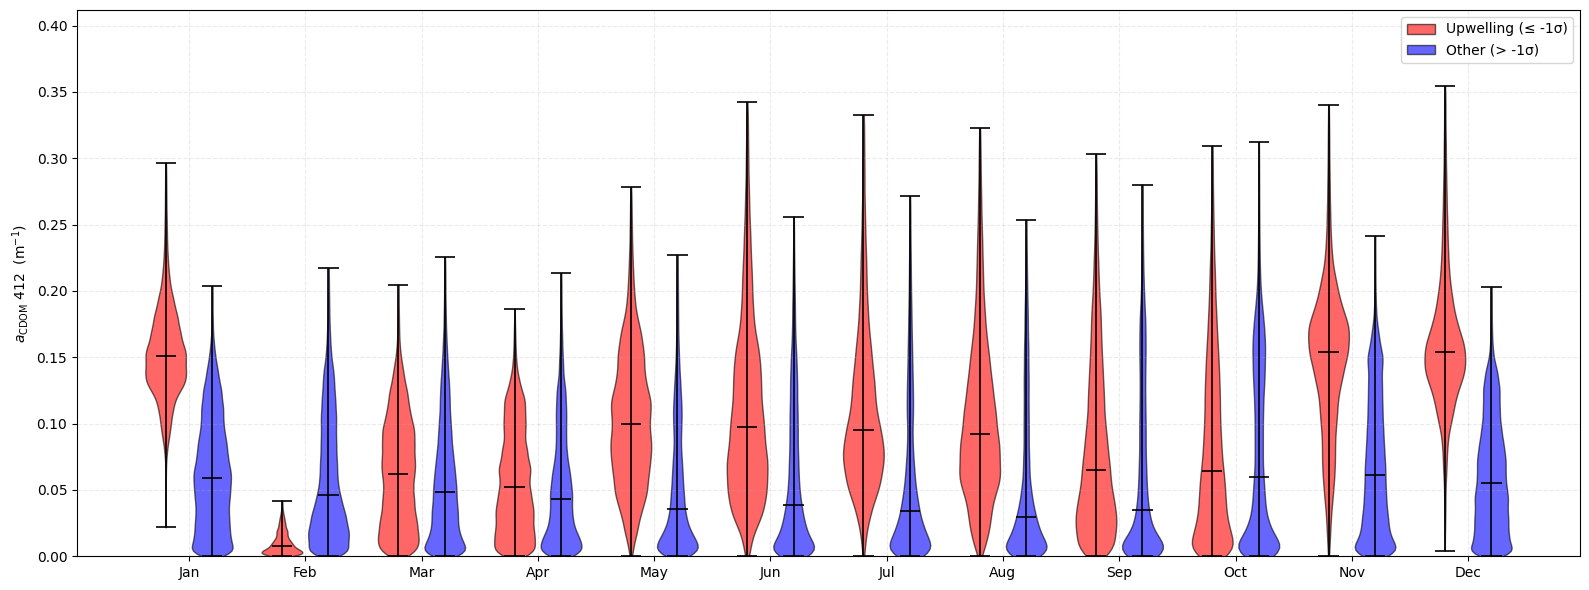

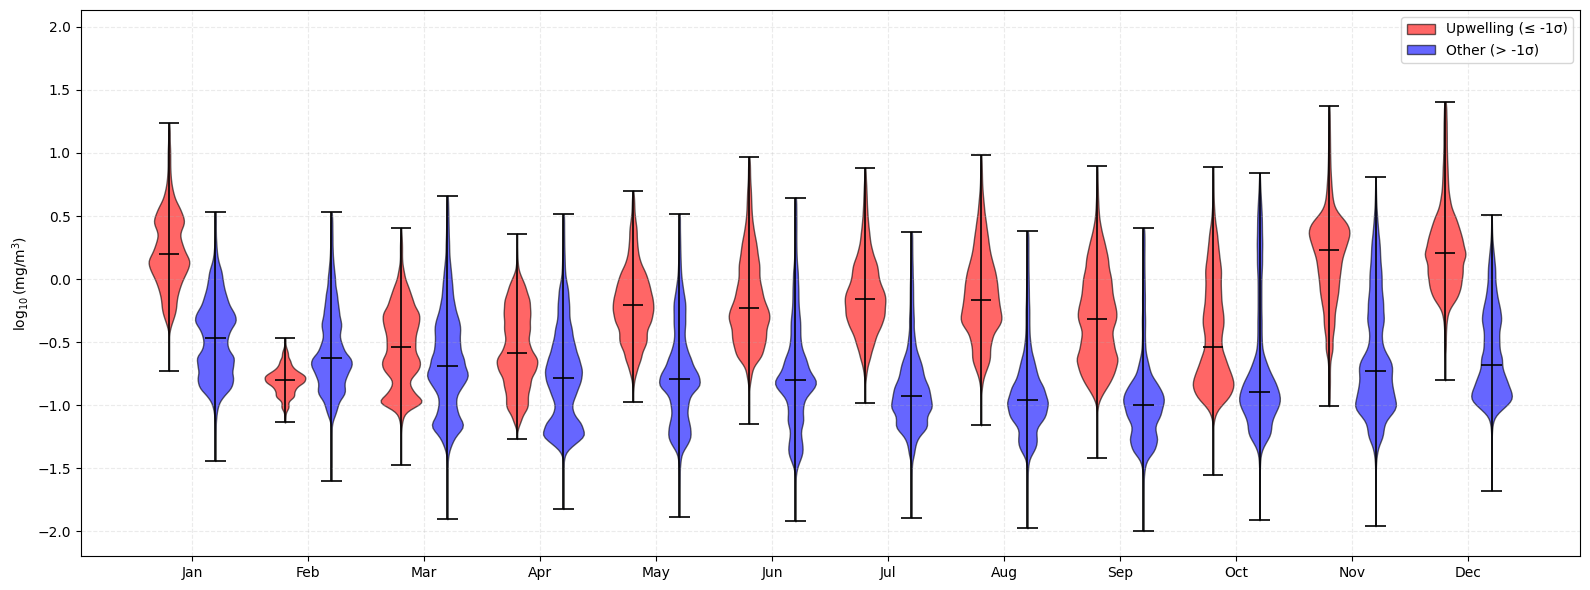

In [23]:
# 1. Extract data for all years
all_yearly_data = []

for year in range(2010, 2020):
    year_data = extract_year_data(year, df)
    if year_data:
        all_yearly_data.append(year_data)

# 2. Determine global limits for each feature based on trimmed data
s275_list = [{'labels': yd['labels'], 'is_upwelling': yd['is_upwelling'], 'values': yd['s275']} for yd in all_yearly_data]
s300_list = [{'labels': yd['labels'], 'is_upwelling': yd['is_upwelling'], 'values': yd['s300']} for yd in all_yearly_data]
a412_list = [{'labels': yd['labels'], 'is_upwelling': yd['is_upwelling'], 'values': yd['a412']} for yd in all_yearly_data]
chlor_list = [{'labels': yd['chlor_labels'], 'is_upwelling': yd['chlor_is_upwelling'], 'values': yd['chlor']} for yd in all_yearly_data]

limits = {
    's275': get_trimmed_limits(s275_list),
    's300': get_trimmed_limits(s300_list),
    'a412': get_trimmed_limits(a412_list),
    'chlor': get_trimmed_limits(chlor_list)
}

print(f"Global limits computed:\nS275: {limits['s275']}\nS300: {limits['s300']}\na412: {limits['a412']}\nChlor: {limits['chlor']}")

# 3. Plot all figures with standardized limits
all_figures = []

for yd in all_yearly_data:
    year_str = yd['year']
    print(f"Generating plots for {year_str}...")
    
    fig1 = plot_violin(year_str, yd['s275'], yd['labels'], yd['is_upwelling'], 'CDOM S275:295', r'$S_{275-295}$ $\text{ (nm}^{-1}\text{)}$', limits['s275'])
    if fig1: all_figures.append(fig1)
        
    fig2 = plot_violin(year_str, yd['s300'], yd['labels'], yd['is_upwelling'], 'CDOM S300:600', r'$S_{300-600}$ $\text{ (nm}^{-1}\text{)}$', limits['s300'])
    if fig2: all_figures.append(fig2)
        
    fig3 = plot_violin(year_str, yd['a412'], yd['labels'], yd['is_upwelling'], 'CDOM a(412)', r'$a_{\text{CDOM}}$ 412 $\text{ (m}^{-1}\text{)}$', limits['a412'])
    if fig3: all_figures.append(fig3)
        
    fig4 = plot_violin(year_str, yd['chlor'], yd['chlor_labels'], yd['chlor_is_upwelling'], 'Log10 Chlorophyll', r'$\log_{10}(\text{mg/m}^3)$', limits['chlor'])
    if fig4: all_figures.append(fig4)


In [24]:
import os

# Create figures directory if it doesn't exist
os.makedirs('figures', exist_ok=True)

# Save all generated figures
for fig, name in all_figures:
    fig.savefig(os.path.join('figures', name), bbox_inches='tight', dpi=300)
    
print(f"Saved {len(all_figures)} figures to figures/ directory.")

Saved 40 figures to figures/ directory.


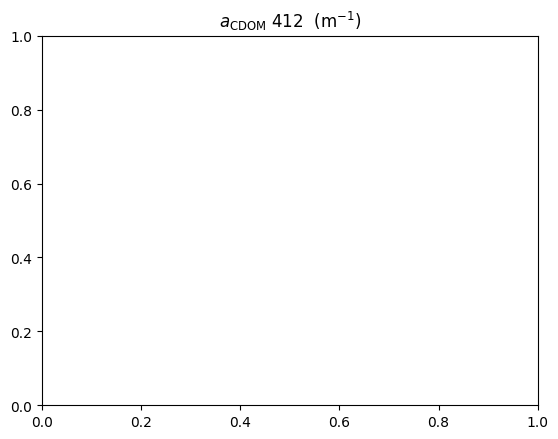

In [25]:
poop = plt.Figure(figsize=(10, 6))
poop = plt.title(r'$a_{\text{CDOM}}$ 412 $\text{ (m}^{-1}\text{)}$')